# Bank Telemarketing Campaign Prediction: <br>Predicting Term Deposit Subscriptions Using a Stacked Ensemble <br>(Team 13)

### Edwin Lim Jia Xian, Chee Keng Wai Cornelius, Lau Tze Chong Deuel, Tan Yi Cheng


# Project Overview: Bank Marketing Prediction System

## Feature Engineering and Data Preprocessing

Our feature engineering pipeline employed VIF (Variance Inflation Factor) analysis to address severe multicollinearity among macroeconomic indicators, with `euribor3m` (VIF: 64.5), `emp.var.rate` (33.1), and `nr.employed` (31.8) showing problematic correlations. We dropped `pdays`, `emp.var.rate`, `nr.employed`, and `cons.price.idx` (all VIF > 10) for linear models while retaining `euribor3m` and `cons.conf.idx` as economic signals. Critically, we excluded `duration` entirely to prevent data leakage, as this feature is only known post-contact and creates unrealistic prospective performance.

Missing values encoded as "unknown" were retained as distinct categories rather than imputed, as missingness itself carries predictive signal—customers who didn't disclose loan/housing status represent a meaningful behavioral pattern. We engineered a binary `contacted_before` indicator from `pdays` to capture contact history more interpretably. The 12 duplicate rows (0.03%) were removed during preprocessing.

Feature visualization was conducted through multiple lenses: VIF analysis for multicollinearity detection, Logistic Regression coefficients revealing `euribor3m` (-0.734) as the strongest predictor and `contacted_before` (+0.381) as the leading positive signal, and threshold analysis plots (F1-score curves, Precision-Recall curves, profit optimization) demonstrating model behavior across decision boundaries.

We implemented a **dual preprocessing track** tailored to each model family's assumptions: (1) Mean target encoding for tree-based models (Random Forest, XGBoost), replacing categories with their mean target value computed on training folds; (2) Binary encoding + StandardScaler normalization for linear and distance-based models (Logistic Regression, KNN, Naive Bayes). All transformation parameters were fitted exclusively on training data within each CV fold to ensure zero information leakage.

## Related Work and Novel Contributions

This project builds upon three foundational studies while addressing critical methodological gaps:

**Referenced Studies:**
1. **Moro, Cortez, & Rita (2014)** - "A Data-Driven Approach to Predict the Success of Bank Telemarketing" (*Decision Support Systems*)  
   Established the UCI Bank Marketing benchmark with neural networks achieving AUC ≈ 0.80, recovering 79% of subscribers from top-scoring half.

2. **Xie et al. (2023)** - "How to Improve the Success of Bank Telemarketing" (*Computers & Industrial Engineering*)  
   Demonstrated hybrid Random Subspace–Multi-Boosting ensemble superiority and identified contact month/job type as key drivers via Partial Dependence Plots.

3. **Peter et al. (2025)** - "Predicting Customer Subscription Using Ensemble Learning Models" (*Journal of Data Science and AI*)  
   Reported stacking ensembles reaching AUC 0.9491.

**Addressing Three Critical Limitations:**

1. **Data Leakage Elimination:** Unlike prior work that routinely included `duration`, we excluded this feature entirely. While it dramatically improves apparent performance, `duration` is only observable post-contact and creates unrealistic prospective predictions—rendering models undeployable in production targeting scenarios.

2. **Nested Cross-Validation for Unbiased Evaluation:** We implemented nested 5×5 CV rather than standard CV to rigorously decouple hyperparameter tuning (inner loop GridSearchCV) from generalization estimation (outer loop held-out sets). This eliminates optimism bias that inflates performance metrics when tuning on the same folds used for evaluation.

3. **Economic Grounding and Business Translation:** Moving beyond abstract AUC scores, we translated model predictions into actionable business value using sourced Portuguese banking parameters: €3 call cost (nearshore European BPO rates), €62.50 revenue per conversion (1.25% NIM on €5,000 deposits). This enabled profit-maximizing threshold optimization, call budget allocation analysis, and ROI quantification—demonstrating €12,962 additional profit (+7.6% uplift) and 14,279 calls saved (36.2% reduction) versus baseline.

## Machine Learning Architecture

**Model Selection Rationale:**  
Our stacked generalization ensemble combines four diverse base learners with complementary inductive biases: Random Forest (variance reduction via bagging with `class_weight='balanced'`), XGBoost (gradient boosting for non-linear interactions with `scale_pos_weight`), KNN (non-parametric instance-based perspective), and Gaussian Naive Bayes (probabilistic model suited to categorical features). A standalone Logistic Regression with ℓ2 regularization serves as the interpretable baseline. The meta-classifier (Level-1 Logistic Regression) learns optimal weighting of base predictions across different feature space regions.

**Ensemble Diversity Justification:**  
Despite weaker individual performance (KNN AUC: 0.764, NB: 0.755), these models provide complementary signals with low prediction correlation to tree-based learners (mean pairwise correlation < 0.85). The meta-learner assigns weights reflecting predictive strength: XGBoost (0.42), Random Forest (0.31), KNN (0.18), Naive Bayes (0.09).

**Implementation Rigor:**  
- Dual preprocessing prevents feature representation mismatch between model families
- Out-of-fold (OOF) predictions train the meta-classifier, preventing overfitting
- Nested CV ensures hyperparameter tuning never contaminates test data
- Class imbalance (7.88:1 negative-to-positive ratio) handled via balanced class weights and scale parameters
- All code documented with inline comments explaining VIF-based feature removal, encoding rationale, and leakage prevention
- External sources properly attributed: sklearn implementations, category_encoders, economic parameters from CallForce Global (2023), World Bank (2022), Federal Reserve Bank of St. Louis (2022)

## Experimental Design and Results

**Nested Cross-Validation Framework:**  
Our nested 5×5 stratified CV architecture consists of: (1) **Outer loop** - 5 folds for unbiased generalization estimation, each serving as test set exactly once; (2) **Inner loop** - 5-fold GridSearchCV on outer training partition for hyperparameter selection via AUC-ROC scoring; (3) **Meta-learner training** - OOF predictions from inner CV form meta-features; (4) **Final predictions** - Test predictions averaged across inner folds before stacking. This ensures zero optimism bias across 39,404 total samples.

**Model Performance Comparison:**

| Model | AUC-ROC | Role |
|-------|---------|------|
| **Stacked Ensemble** | **0.8039 ± 0.0049** | **Best** |
| XGBoost | 0.8038 ± 0.0055 | Base learner |
| Random Forest | 0.8009 ± 0.0057 | Base learner |
| Logistic Regression | 0.7890 ± 0.0033 | Baseline |
| KNN | 0.7636 ± 0.0062 | Base learner |
| Naive Bayes | 0.7553 ± 0.0034 | Base learner |

The stacked ensemble achieves 0.8039 (95% CI: 0.794–0.814), consistently outperforming the baseline. Low variance across outer folds (±0.0049) confirms robust generalization. At default 0.5 threshold, the ensemble delivers superior precision (0.378 vs. 0.335) reflecting better probability calibration, though baseline achieves marginally higher recall (0.640 vs. 0.636).

**Threshold Optimization and Business Impact:**  
The ensemble's advantage emerges under profit-maximizing thresholds. At optimal threshold (0.272), the ensemble achieves both higher precision (0.290 vs. 0.278) and higher recall (0.847 vs. 0.781) simultaneously compared to baseline. Business metrics at profit-maximizing thresholds:

| Strategy | Calls Made | Net Profit | Calls Saved |
|----------|-----------|-----------|-------------|
| Random (all) | 39,404 | €169,163 | — |
| Baseline LR | 30,774 | €177,615 | 8,630 (21.9%) |
| **Stacked Ensemble** | **25,125** | **€182,125** | **14,279 (36.2%)** |

The ensemble generates €12,962 additional profit (7.6% uplift) while saving 14,279 calls versus random dialling. Under resource-constrained scenarios (top-10% budget, 3,940 calls), it yields 2,025 conversions (4.40× lift) versus 1,924 for baseline.

**Comparison with Prior Work:**  
Our nested CV AUC of 0.804 aligns with Moro et al. (2014) who achieved ~0.80 with neural networks, and is positioned below Peter et al. (2025) who reported 0.949 but likely included the leaky `duration` feature. Our results demonstrate that rigorous leakage-free validation yields more conservative but deployable performance estimates suitable for production targeting systems.

**Performance Metrics:**  
We employed comprehensive evaluation across technical and business dimensions: AUC-ROC (primary ranking metric under class imbalance), Precision/Recall/F1 (evaluated at both 0.5 and profit-maximizing thresholds), confusion matrices (full TP/TN/FP/FN breakdown), net profit (€182,125 for ensemble vs. €169,163 random), calls saved (36.2% reduction), lift analysis (4.40× for top-10% budget), and Precision-Recall curves. Break-even precision of 4.8% established from €3 cost and €62.50 revenue—comfortably exceeded by all models.

# 1. Exploratory Data Analysis

## 1.1 Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
from datetime import datetime
from pathlib import Path

# Visualisation & Statistics
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Preprocessing
import category_encoders as ce
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, accuracy_score, 
    precision_recall_curve
)


# Save
import pickle

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 1244
np.random.seed(RANDOM_STATE)

# Load the dataset
df = pd.read_csv('../Model & Dataset/dataset.csv')

## 1.2 Dataset Overview

In [2]:
# Display first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0,0,0,telephone,may,mon,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,-1,0,0,telephone,may,mon,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,0,1,0,telephone,may,mon,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,0,0,0,telephone,may,mon,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,0,0,1,telephone,may,mon,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
5,45,services,married,basic.9y,-1,0,0,telephone,may,mon,198,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
6,59,admin.,married,professional.course,0,0,0,telephone,may,mon,139,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
7,41,blue-collar,married,unknown,-1,0,0,telephone,may,mon,217,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
8,24,technician,single,professional.course,0,1,0,telephone,may,mon,380,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
9,25,services,single,high.school,0,1,0,telephone,may,mon,50,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0


In [3]:
# Dataset information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  int64  
 5   housing         41188 non-null  int64  
 6   loan            41188 non-null  int64  
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m 

In [4]:
# Basic statistics for numerical features
print("Statistical Summary - Numerical Features:")
df.describe()

Statistical Summary - Numerical Features:


,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,-0.208653,0.499806,0.127659,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,0.406530,0.545967,0.399297,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,-1.000000,-1.000000,-1.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,0.000000,1.000000,0.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [5]:
# Categorical features summary
print("Statistical Summary - Categorical Features:")
df.describe(include=['object'])

Statistical Summary - Categorical Features:


,job,marital,education,contact,month,day_of_week
count,41188,41188,41188,41188,41188,41188
unique,12,4,8,2,10,5
top,admin.,married,university.degree,cellular,may,thu
freq,10422,24928,12168,26144,13769,8623


## 1.3 Data Quality

In [6]:
# Check for missing values
missing_vals = df.isnull().sum()
missing_pct = 100 * missing_vals / len(df)

missing_df = pd.DataFrame({
    'Missing_Count': missing_vals,
    'Percentage': missing_pct
}).sort_values(by='Missing_Count', ascending=False)

if missing_df['Missing_Count'].sum() == 0:
    print("No NULL/NaN missing values detected")
else:
    print("Missing Values Analysis:")
    print(missing_df[missing_df['Missing_Count'] > 0])

No NULL/NaN missing values detected


In [7]:
# Check for 'unknown' values in categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

print("'Unknown' values in categorical features:")
unknown_counts = {}
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        unknown_counts[col] = {
            'count': unknown_count,
            'percentage': 100 * unknown_count / len(df)
        }

unknown_df = pd.DataFrame(unknown_counts).T
print(unknown_df.sort_values(by='percentage', ascending=False))

'Unknown' values in categorical features:
            count  percentage
education  1731.0    4.202680
job         330.0    0.801204
marital      80.0    0.194231


In [8]:
# Check for -1 encoded unknowns in binary features
binary_features = ['default', 'housing', 'loan']

print("Unknown values (-1) in binary features:")
for feature in binary_features:
    value_counts = df[feature].value_counts().sort_index()
    print(f"\n{feature}:")
    print(value_counts)
    if -1 in value_counts.index:
        print(f"  → Unknown percentage: {100 * value_counts[-1] / len(df):.2f}%")

Unknown values (-1) in binary features:

default:
default
-1     8597
 0    32588
 1        3
Name: count, dtype: int64
  → Unknown percentage: 20.87%

housing:
housing
-1      990
 0    18622
 1    21576
Name: count, dtype: int64
  → Unknown percentage: 2.40%

loan:
loan
-1      990
 0    33950
 1     6248
Name: count, dtype: int64
  → Unknown percentage: 2.40%


In [9]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage: {100 * duplicates / len(df):.2f}%")
else:
    print("No duplicate rows found!")

Duplicate rows: 12
Percentage: 0.03%


## Target Variable Analysis

In [10]:
# Target distribution
target_counts = df['y'].value_counts().sort_index()
target_pcts = df['y'].value_counts(normalize=True).sort_index() * 100

print("Target Variable Distribution:")
print("="*50)
print(f"Class 0 (No subscription): {target_counts[0]:,} ({target_pcts[0]:.2f}%)")
print(f"Class 1 (Subscription):    {target_counts[1]:,} ({target_pcts[1]:.2f}%)")
print("="*50)
print(f"\nClass Imbalance Ratio: {target_counts[0] / target_counts[1]:.2f}:1")
print(f"Minority class percentage: {target_pcts[1]:.2f}%")

Target Variable Distribution:
Class 0 (No subscription): 36,548 (88.73%)
Class 1 (Subscription):    4,640 (11.27%)

Class Imbalance Ratio: 7.88:1
Minority class percentage: 11.27%


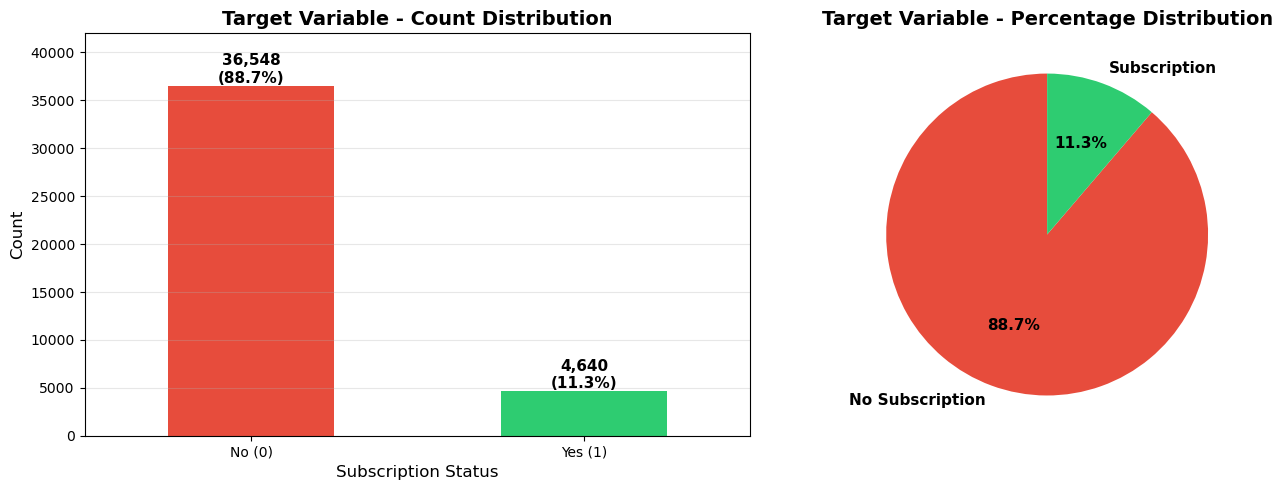

In [11]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Target Variable - Count Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subscription Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 42_000)

# Add value labels on bars
for i, (idx, val) in enumerate(target_counts.items()):
    axes[0].text(i, val, f'{val:,}\n({target_pcts[idx]:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
colors = ['#e74c3c', '#2ecc71']
axes[1].pie(target_counts, labels=['No Subscription', 'Subscription'], 
           autopct='%1.1f%%', startangle=90, colors=colors,
           textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Target Variable - Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Univariate Analysis (Numerical)

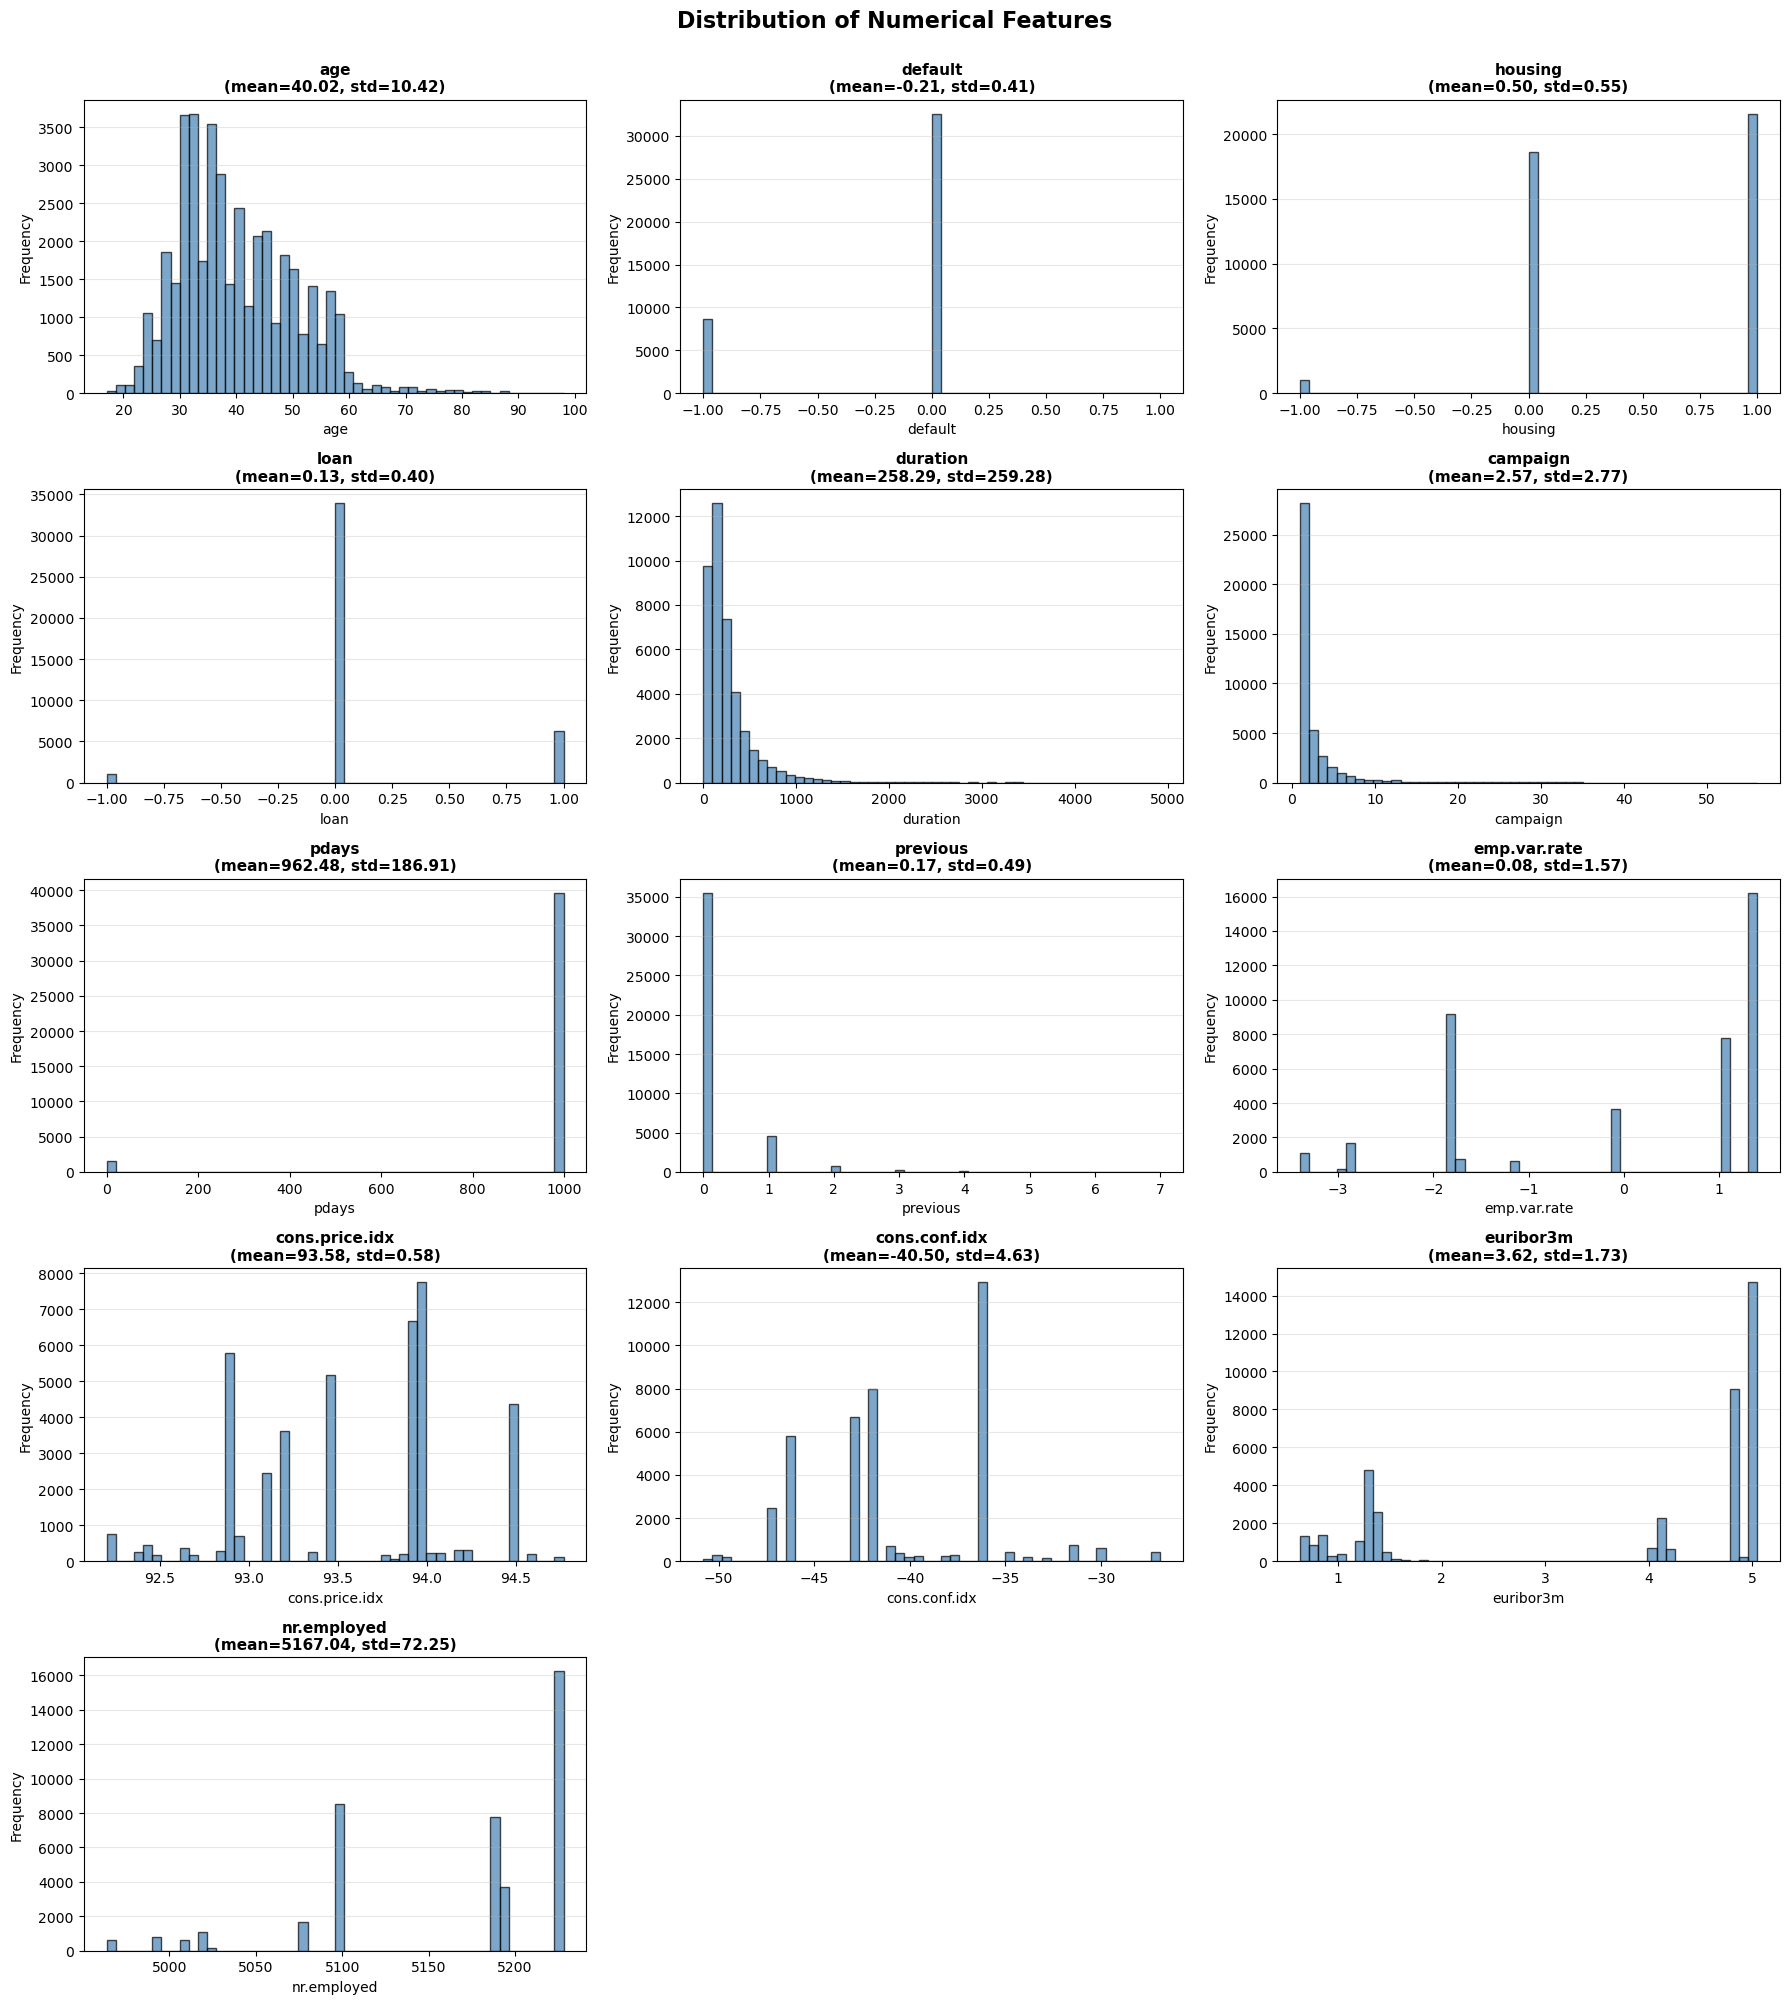

In [12]:
# Identify numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('y')  # Remove target

# Distribution plots for numerical features
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col}\n(mean={df[col].mean():.2f}, std={df[col].std():.2f})', 
                     fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

# Hide extra subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

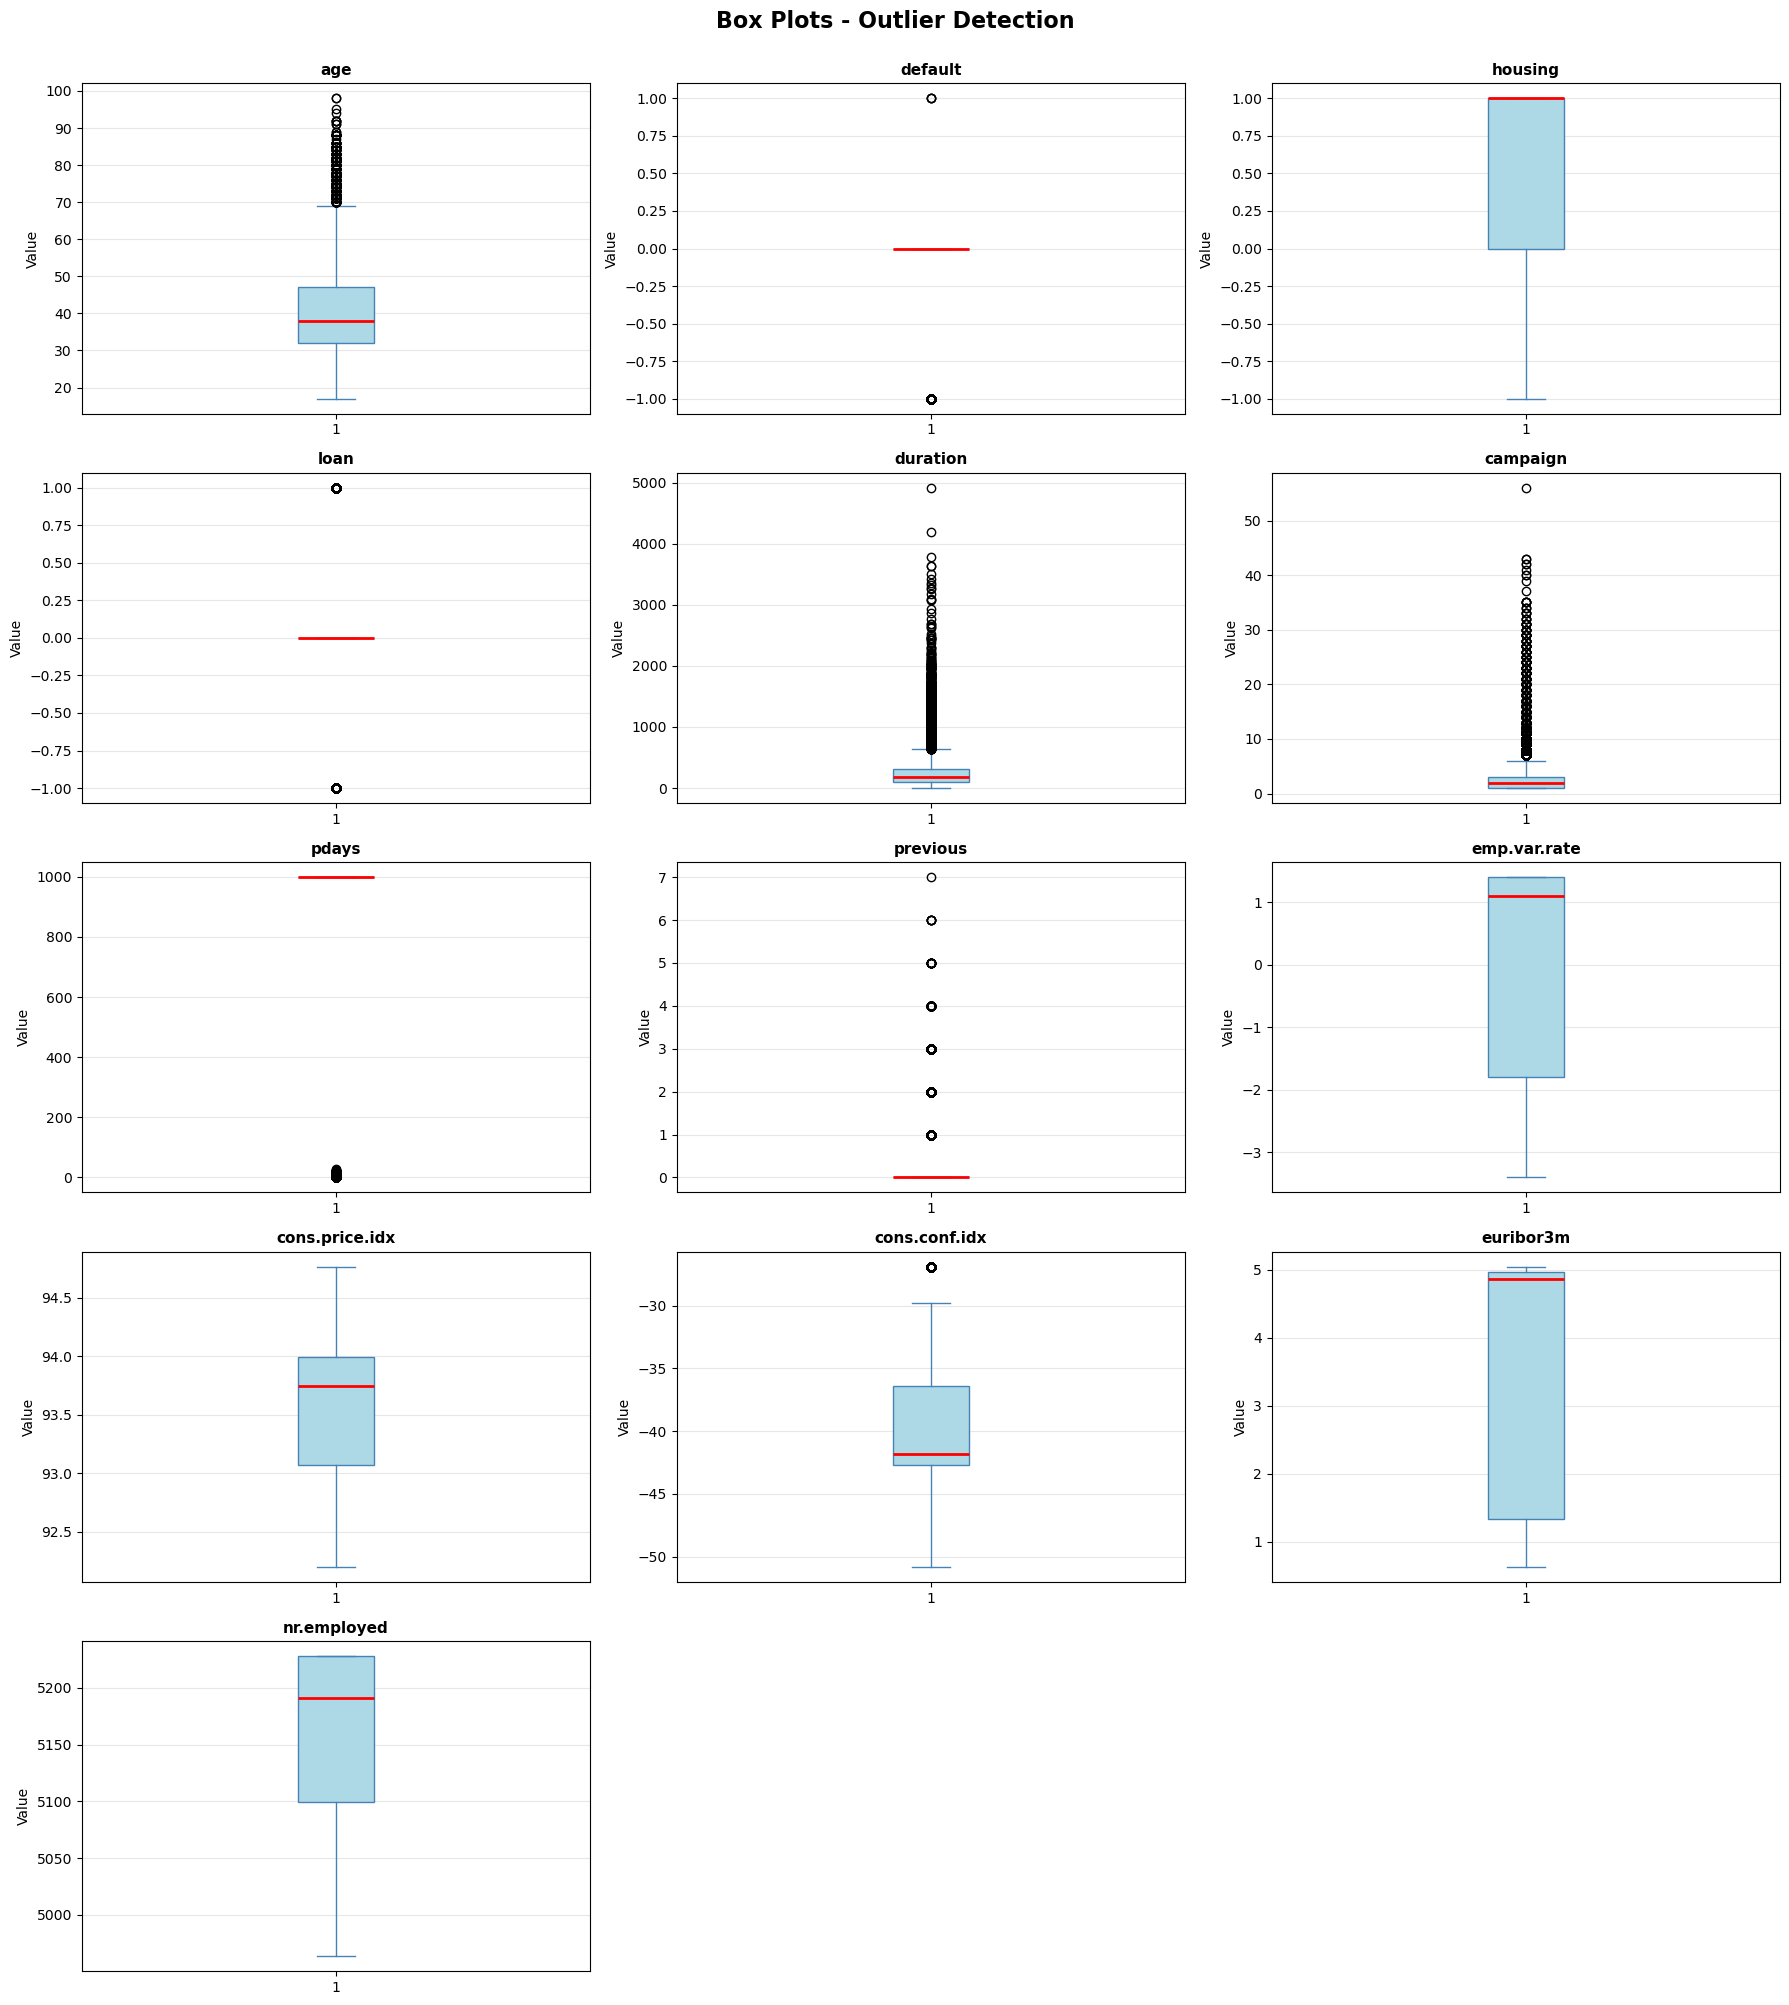

In [13]:
# Box plots to identify outliers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='steelblue'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='steelblue'),
                   capprops=dict(color='steelblue'))
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

# Hide extra subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### pdays analysis

In [14]:
pdays_999_count = (df['pdays'] == 999).sum()
pdays_999_pct = 100 * pdays_999_count / len(df)

print("\nSPECIAL ANALYSIS: 'pdays' feature")
print("="*50)
print(f"Records with pdays = 999 (never contacted): {pdays_999_count:,} ({pdays_999_pct:.2f}%)")
print(f"Records with pdays < 999 (previously contacted): {len(df) - pdays_999_count:,} ({100 - pdays_999_pct:.2f}%)")

if pdays_999_count > 0:
    print("\nStatistics for pdays < 999 (previously contacted clients):")
    pdays_contacted = df[df['pdays'] < 999]['pdays']
    print(f"  Mean:   {pdays_contacted.mean():.2f} days")
    print(f"  Median: {pdays_contacted.median():.2f} days")
    print(f"  Min:    {pdays_contacted.min():.2f} days")
    print(f"  Max:    {pdays_contacted.max():.2f} days")


SPECIAL ANALYSIS: 'pdays' feature
Records with pdays = 999 (never contacted): 39,673 (96.32%)
Records with pdays < 999 (previously contacted): 1,515 (3.68%)

Statistics for pdays < 999 (previously contacted clients):
  Mean:   6.01 days
  Median: 6.00 days
  Min:    0.00 days
  Max:    27.00 days


## Univariate Analysis (Categorical)

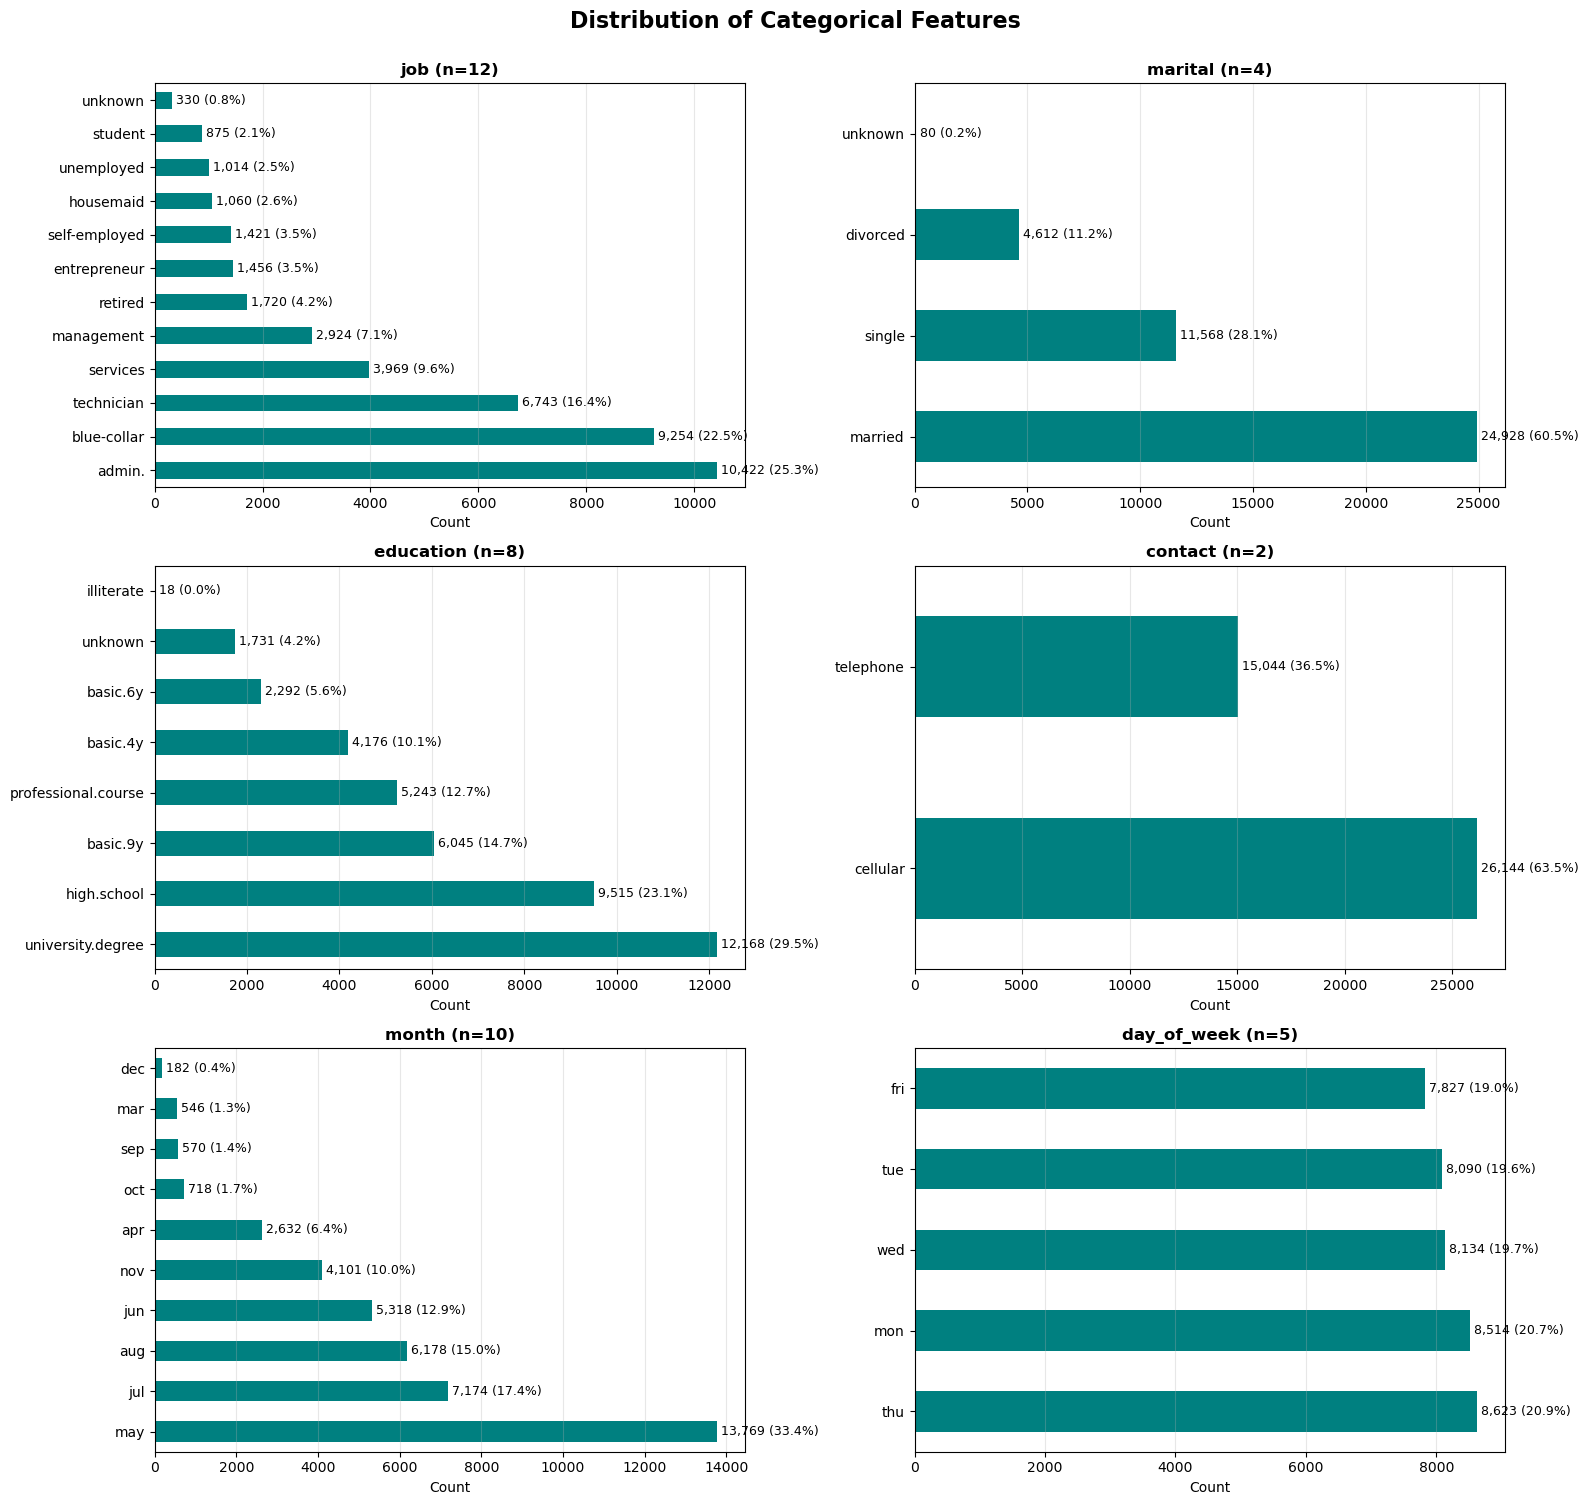

In [15]:
# Identify categorical features
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Distribution of categorical features
n_cols = 2
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    value_counts.plot(kind='barh', ax=axes[i], color='teal')
    axes[i].set_title(f'{col} (n={df[col].nunique()})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Count', fontsize=10)
    axes[i].set_ylabel('')
    axes[i].grid(axis='x', alpha=0.3)
    
    # Add percentage labels
    total = len(df)
    for j, (idx, val) in enumerate(value_counts.items()):
        pct = 100 * val / total
        axes[i].text(val, j, f' {val:,} ({pct:.1f}%)', 
                    va='center', fontsize=9)

# Hide extra subplots
for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Bivariate Analysis (Numerical vs Target)

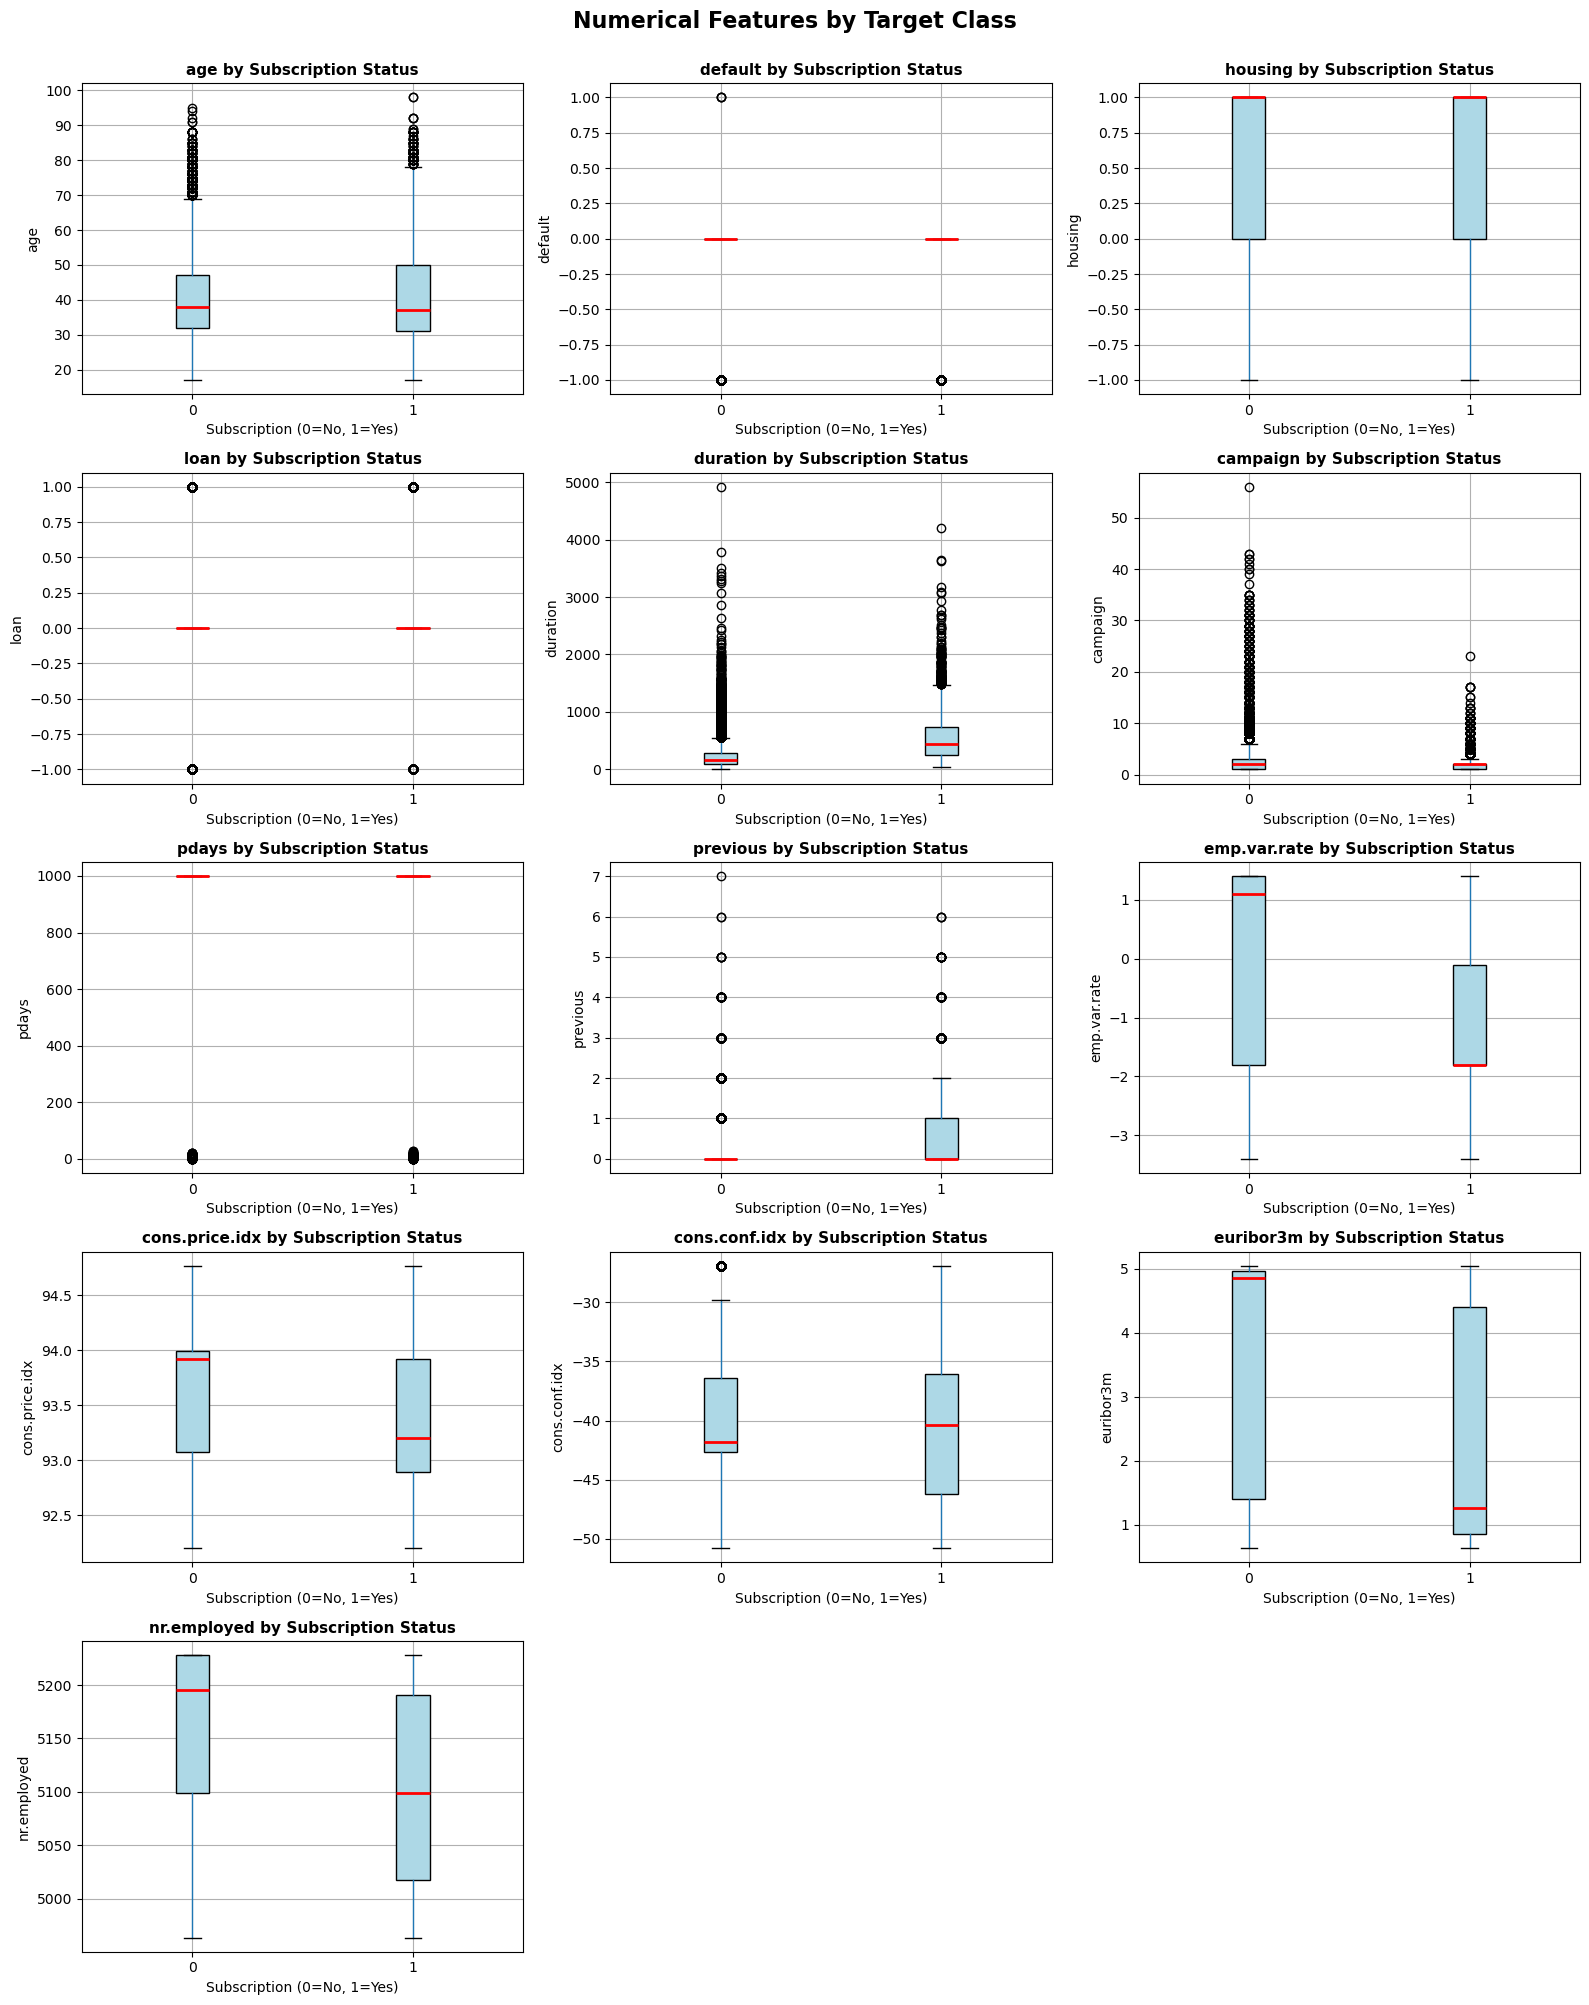

In [16]:
# Compare numerical features by target class
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='y', ax=axes[i], patch_artist=True,
              boxprops=dict(facecolor='lightblue'),
              medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} by Subscription Status', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Subscription (0=No, 1=Yes)', fontsize=10)
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].get_figure().suptitle('')

# Hide extra subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Numerical Features by Target Class', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Bivariate Analysis (Categorical vs Target)

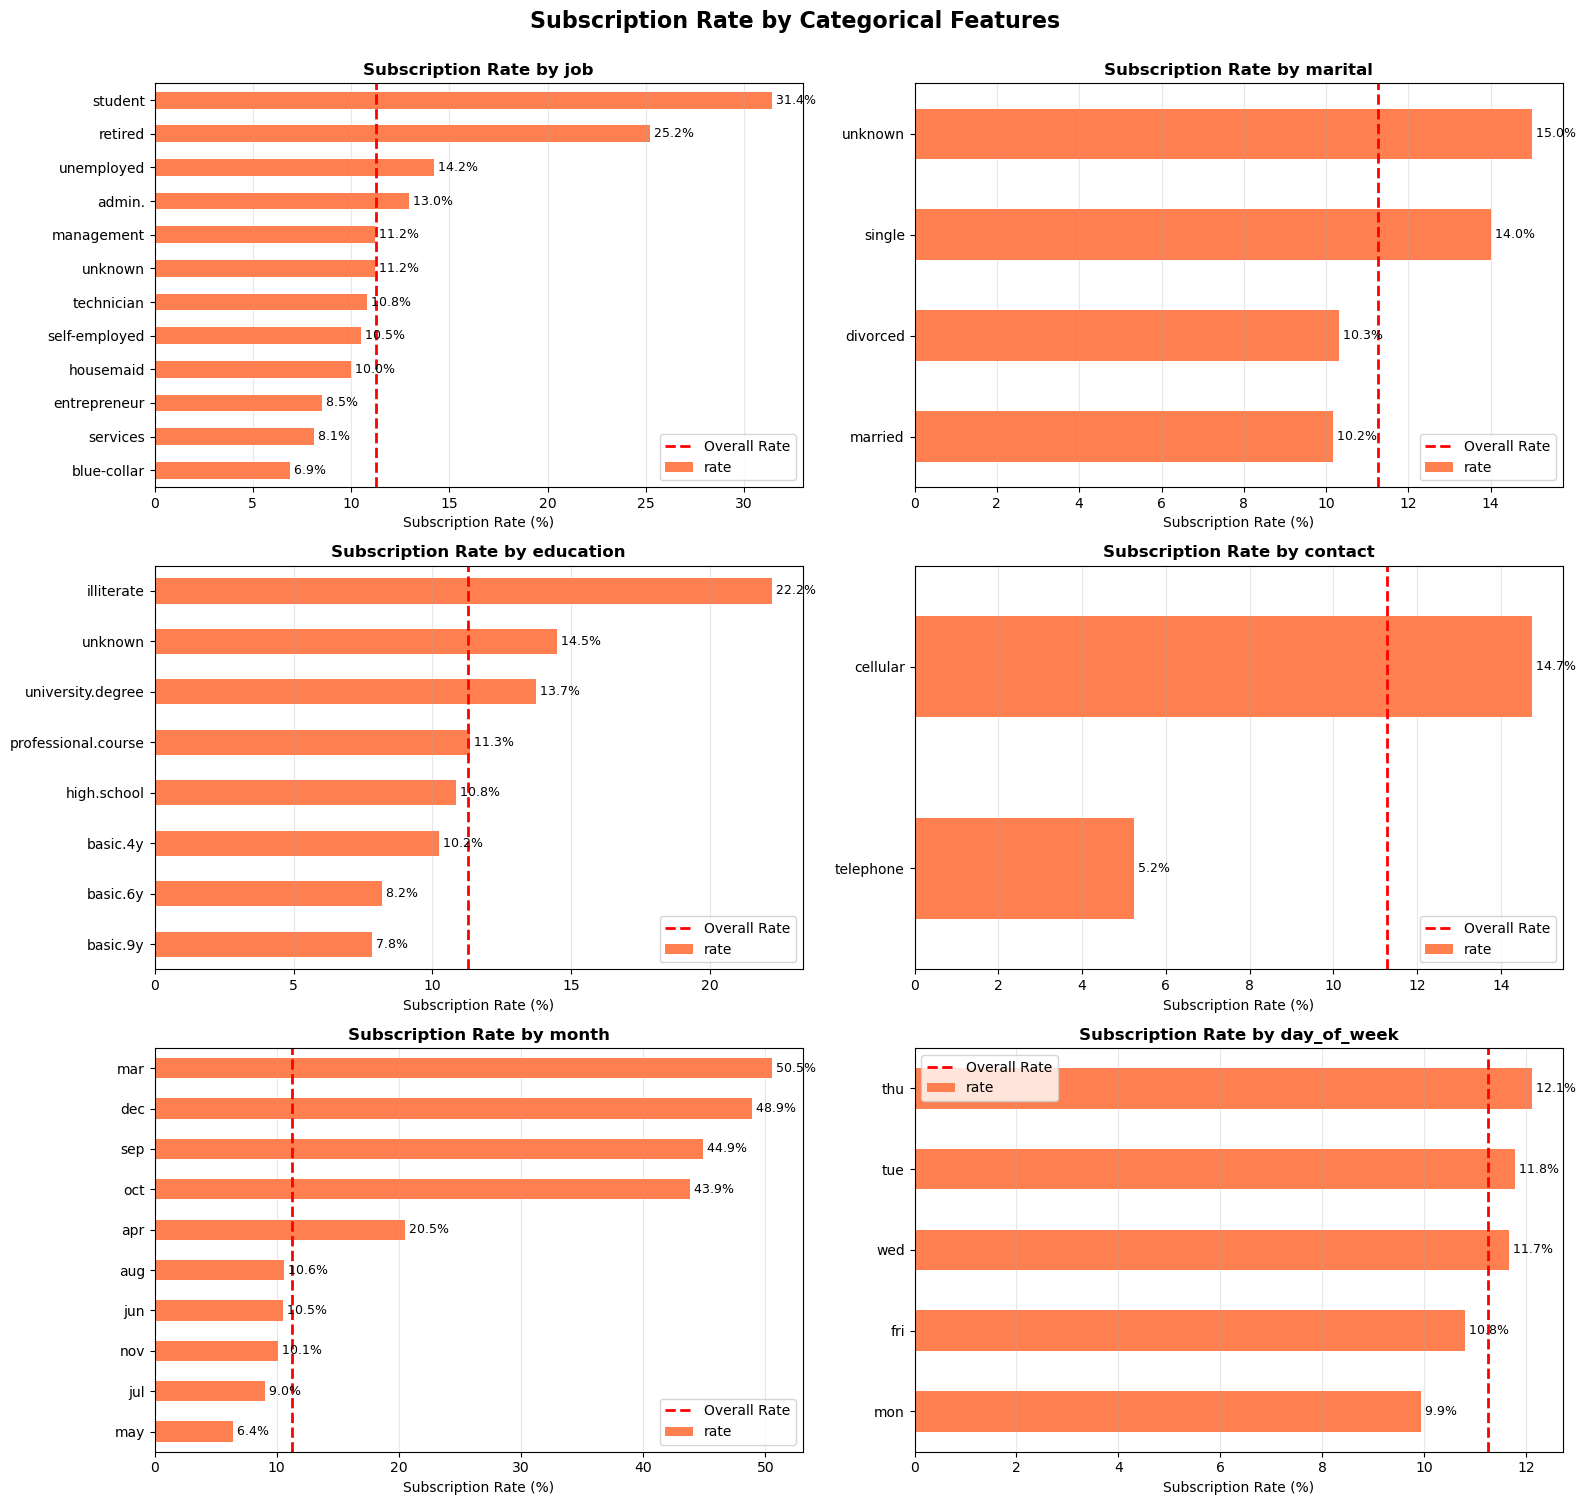

In [17]:
# Subscription rate by categorical features
n_cols = 2
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Calculate subscription rate by category
    sub_rate = df.groupby(col)['y'].agg(['sum', 'count'])
    sub_rate['rate'] = 100 * sub_rate['sum'] / sub_rate['count']
    sub_rate = sub_rate.sort_values('rate', ascending=True)
    
    sub_rate['rate'].plot(kind='barh', ax=axes[i], color='coral')
    axes[i].set_title(f'Subscription Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Subscription Rate (%)', fontsize=10)
    axes[i].set_ylabel('')
    axes[i].axvline(df['y'].mean() * 100, color='red', linestyle='--', 
                   linewidth=2, label='Overall Rate')
    axes[i].legend()
    axes[i].grid(axis='x', alpha=0.3)
    
    # Add percentage labels
    for j, (idx, val) in enumerate(sub_rate['rate'].items()):
        axes[i].text(val, j, f' {val:.1f}%', va='center', fontsize=9)

# Hide extra subplots
for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Subscription Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Correlation Analysis

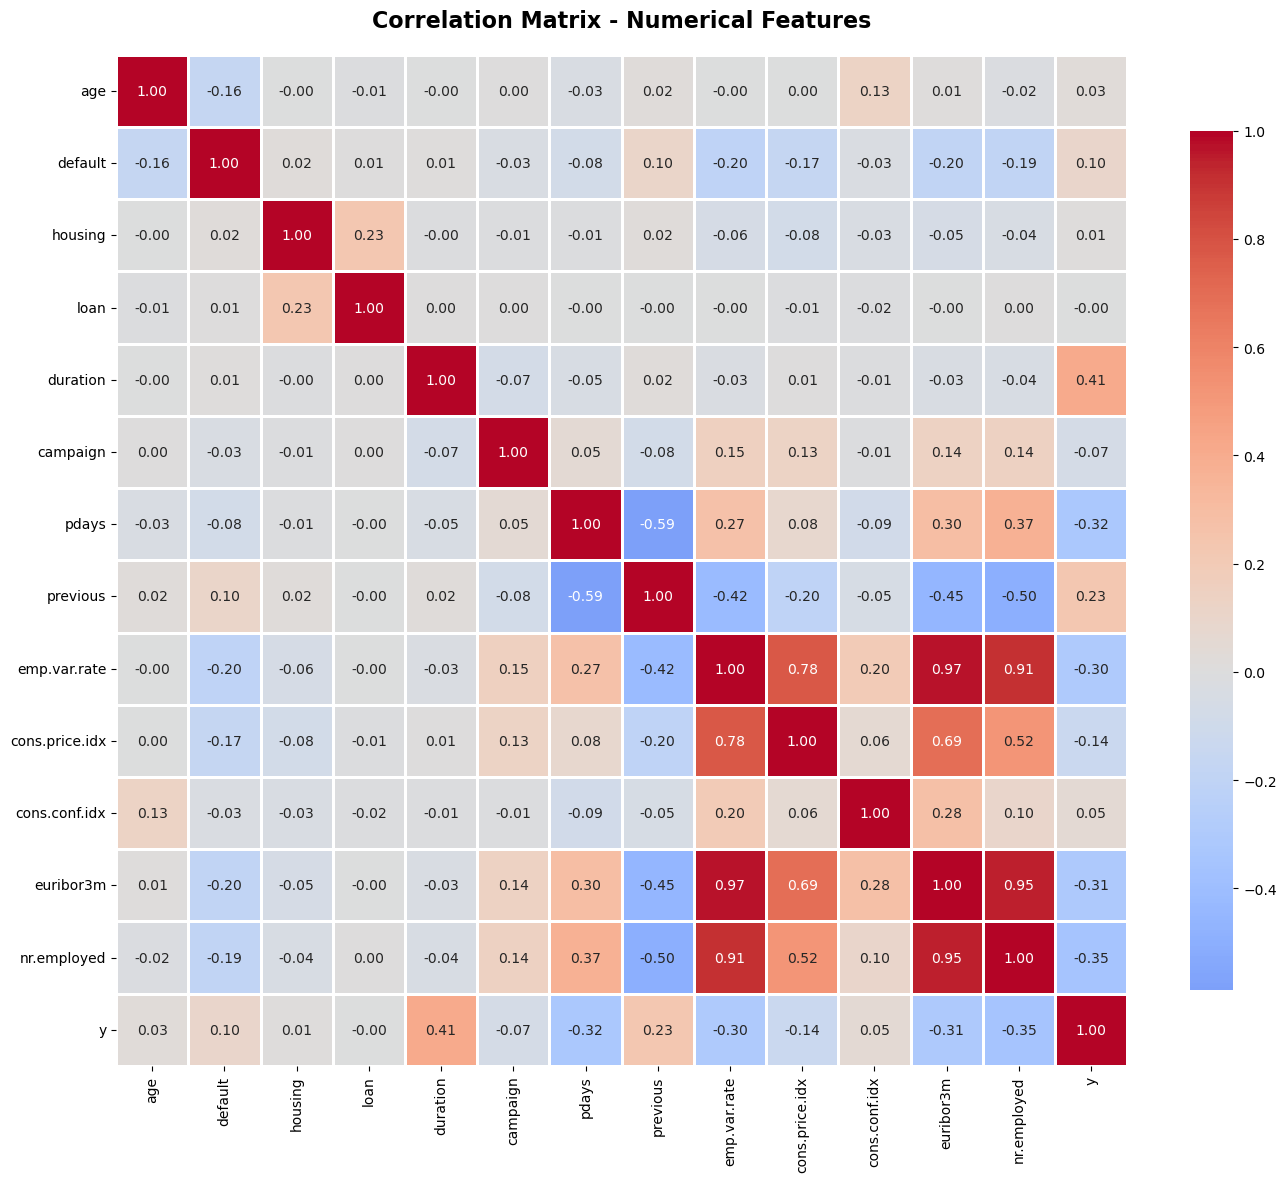

In [18]:
# Correlation matrix for numerical features
correlation_matrix = df[numerical_cols + ['y']].corr()

# Full correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Variance Inflation Factor  Analysis

In [19]:
# Standardize for VIF calculation
scaler_vif = StandardScaler()
vif_data = pd.DataFrame(
    scaler_vif.fit_transform(df[numerical_cols]),
    columns=numerical_cols
)

# Calculate VIF
vif_results = []
for i, col in enumerate(numerical_cols):
    vif_value = variance_inflation_factor(vif_data.values, i)
    vif_results.append({
        'Feature': col,
        'VIF': vif_value
    })

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)

print("VIF Scores (sorted by severity):")
print("=" * 80)
print(vif_df.to_string(index=False))

# Identify problematic features
high_vif = vif_df[vif_df['VIF'] > 10]
moderate_vif = vif_df[(vif_df['VIF'] > 5) & (vif_df['VIF'] <= 10)]

VIF Scores (sorted by severity):
       Feature       VIF
     euribor3m 64.464959
  emp.var.rate 33.131872
   nr.employed 31.783813
cons.price.idx  6.383155
 cons.conf.idx  2.655072
      previous  1.796827
         pdays  1.615669
       default  1.078907
       housing  1.064511
          loan  1.055684
           age  1.050260
      campaign  1.038475
      duration  1.009521


# Data Transformation

In [20]:
# Drop duration
df = df.drop(columns=['duration'])

# Drop duplicate rows
df = df.drop_duplicates()

# Separate dataset into X and y
X = df.drop('y', axis=1)
y = df['y'].values

# Create a new categorical/binary column for contact history
X['contacted_before'] = (X['pdays'] != 999).astype(int)

# Convert the 999 outlier to -1 to stabilize linear models
X['pdays'] = X['pdays'].replace({999: -1})

# Drop economic features
X = X.drop(columns=['emp.var.rate', 'nr.employed', 'cons.price.idx', 'pdays'])

# Convert -1 encoded columns to categorical strings
# Keep 'unknown' as its own category for housing and loan
X['housing'] = X['housing'].map({-1: 'unknown', 0: 'no', 1: 'yes'})
X['loan'] = X['loan'].map({-1: 'unknown', 0: 'no', 1: 'yes'})
X['default'] = X['default'].map({-1: 'unknown', 0: 'known', 1: 'known'})


print(f'Shape: {X.shape}')
print(f'Target distribution: {pd.Series(y).value_counts().to_dict()}')
print(f'Imbalance ratio: {(y==0).sum() / (y==1).sum():.2f}:1')

print(f'\nCategorical feature distributions:')
print(f"  default: {X['default'].value_counts().to_dict()}")
print(f"  housing: {X['housing'].value_counts().to_dict()}")
print(f"  loan: {X['loan'].value_counts().to_dict()}")

print(f'\nAll Features ({len(X.columns)}):')
print(list(X.columns))

Shape: (39404, 15)
Target distribution: {0: 34806, 1: 4598}
Imbalance ratio: 7.57:1

Categorical feature distributions:
  default: {'known': 31138, 'unknown': 8266}
  housing: {'yes': 20561, 'no': 17863, 'unknown': 980}
  loan: {'no': 32248, 'yes': 6176, 'unknown': 980}

All Features (15):
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'cons.conf.idx', 'euribor3m', 'contacted_before']


In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39404 entries, 0 to 41187
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               39404 non-null  int64  
 1   job               39404 non-null  object 
 2   marital           39404 non-null  object 
 3   education         39404 non-null  object 
 4   default           39404 non-null  object 
 5   housing           39404 non-null  object 
 6   loan              39404 non-null  object 
 7   contact           39404 non-null  object 
 8   month             39404 non-null  object 
 9   day_of_week       39404 non-null  object 
 10  campaign          39404 non-null  int64  
 11  previous          39404 non-null  int64  
 12  cons.conf.idx     39404 non-null  float64
 13  euribor3m         39404 non-null  float64
 14  contacted_before  39404 non-null  int64  
dtypes: float64(2), int64(4), object(9)
memory usage: 4.8+ MB


# Model Training & Methodology

```
STACKED ENSEMBLE
│
├── BASE LAYER (4 models)
│   │
│   ├── Random Forest (RF)
│   │   ├── Encoding: Ordinal
│   │   ├── Hyperparameters:
│   │   │   ├── n_estimators: [100, 200, 500]
│   │   │   ├── max_depth: [10, None]
│   │   │   └── class_weight: 'balanced'
│   │   └── Total combinations: 6
│   │
│   ├── K-Nearest Neighbors (KNN)
│   │   ├── Encoding: One-hot + Scaled
│   │   ├── Hyperparameters:
│   │   │   ├── n_neighbors: [30, 50]
│   │   │   └── weights: ['uniform', 'distance']
│   │   └── Total combinations: 4
│   │
│   ├── XGBoost (XGB)
│   │   ├── Encoding: Ordinal
│   │   ├── Hyperparameters:
│   │   │   ├── n_estimators: [100, 200, 300]
│   │   │   ├── learning_rate: [0.05, 0.1]
│   │   │   ├── max_depth: [3, 5]
│   │   │   ├── min_child_weight: [1, 3]
│   │   │   └── scale_pos_weight: n_negative / n_positive (per fold)
│   │   └── Total combinations: 36
│   │
│   └── Naive Bayes (NB)
│       ├── Encoding: One-hot + Scaled
│       ├── Hyperparameters:
│       │   └── var_smoothing: [1e-10, 3.16e-10, ..., 1e-08] (5 values)
│       └── Total combinations: 5
│
└── META LAYER
    └── Logistic Regression
        ├── Input: Base model predictions (4 features)
        ├── Learns: Optimal linear combination of base models
        └── max_iter: 1000
```

## Hyperparameter Grid

In [22]:
# Hyperparameter grids (larger, ~15mins run time)
GRIDS = {
    'rf': {
        'n_estimators':       [100, 300, 500],
        'max_depth':          [10, None],
    },
    'lr': {
        'C': np.logspace(-3, 2, 5).tolist(),
        'penalty': ['l2'],
    },
    'knn': {
        'n_neighbors': [10, 20, 30, 40, 50],
        'weights': ['uniform', 'distance'],
    },
    'xgb': {
        'n_estimators':       [100, 300],
        'learning_rate':      [0.01, 0.05, 0.1],
    },
    'nb': {
        'var_smoothing': np.logspace(-10, -8, 5).tolist(),
    },
}

print('Hyperparameter grids defined')
for name, grid in GRIDS.items():
    n_combos = np.prod([len(v) for v in grid.values()])
    print(f'  {name:5s}: {n_combos:3.0f} combinations')

Hyperparameter grids defined
  rf   :   6 combinations
  lr   :   5 combinations
  knn  :  10 combinations
  xgb  :   6 combinations
  nb   :   5 combinations


## Helper Functions

In [23]:
# Helper Functions

def preprocess(X_tr, X_val, y_tr):
    """
    Fit all encoders/scalers on X_tr only, transform both.
    Returns two dataset pairs: (tree, linear) for model diversity.
    """
    X_tr = X_tr.copy()
    X_val = X_val.copy()
    
    cat_cols = X_tr.select_dtypes(include=['object', 'category']).columns.tolist()

    # Dataset 1: TREE (Target Encoding) - for rf and xgb
    X_tr_tree = X_tr.copy()
    X_val_tree = X_val.copy()

    if cat_cols:
        te = ce.TargetEncoder(cols=cat_cols)
        X_tr_tree[cat_cols] = te.fit_transform(X_tr_tree[cat_cols], y_tr)
        X_val_tree[cat_cols] = te.transform(X_val_tree[cat_cols])

    X_tr_tree = X_tr_tree.values
    X_val_tree = X_val_tree.values

    # Dataset 2: LINEAR (One-Hot + StandardScaler) - for base model (lr), knn, and nb
    X_tr_linear = pd.get_dummies(X_tr, columns=cat_cols, drop_first=True)
    X_val_linear = pd.get_dummies(X_val, columns=cat_cols, drop_first=True)
    
    X_tr_linear, X_val_linear = X_tr_linear.align(
        X_val_linear, join='left', axis=1, fill_value=0
    )

    scaler_linear = StandardScaler()
    X_tr_linear = scaler_linear.fit_transform(X_tr_linear)
    X_val_linear = scaler_linear.transform(X_val_linear)

    return (
        (X_tr_tree, X_val_tree),
        (X_tr_linear, X_val_linear),
    )


def run_gridsearch(estimator, param_grid, X_tr, y_tr, name):
    """
    Runs GridSearchCV on outer train set using inner folds.
    Returns best estimator (already re-fit on full X_tr).
    """
    inner_cv = StratifiedKFold(
        n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE
    )
    gs = GridSearchCV(
        estimator,
        param_grid,
        cv=inner_cv,
        scoring='roc_auc',
        refit=True,
        n_jobs=-1,
        verbose=0,
    )
    gs.fit(X_tr, y_tr)
    n_combos = len(gs.cv_results_['params'])
    print(f'      {name:15s} best: {gs.best_params_}  '
          f'(inner AUC: {gs.best_score_:.4f})')
    return gs.best_estimator_

## Nested CV

```
NESTED CV (5 × 5)
│
├─ Outer StratifiedKFold (5 folds)  ← Unbiased performance estimation
│   └── For each outer fold k ∈ {1, 2, 3, 4, 5}:
│       │
│       ├── Split data (stratified):
│       │   ├── Train_outer (80%): ~32,000 samples
│       │   └── Test_outer (20%): ~8,000 samples
│       │
│       ├── Preprocessing:
│       │   ├── Fit encoders/scalers on Train_outer ONLY
│       │   ├── Transform Train_outer → (X_train_tree, X_train_linear)
│       │   └── Transform Test_outer → (X_test_tree, X_test_linear)
│       │
│       ├── Compute class weights:
│       │   └── pos_weight = n_negative / n_positive ≈ 7.9
│       │
│       ├── Inner StratifiedKFold (5 folds)  ← Hyperparameter tuning
│       │   └── For each model ∈ {LR_baseline, RF, KNN, XGB, NB}:
│       │       │
│       │       ├── GridSearchCV on Train_outer:
│       │       │   ├── 5-fold CV for each param combination
│       │       │   ├── Scoring: ROC-AUC
│       │       │   └── Select best params
│       │       │
│       │       └── Refit on full Train_outer with best params
│       │
│       ├── OOF (Out-of-Fold) Generation  ← Meta-features
│       │   │
│       │   ├── Initialize:
│       │   │   ├── meta_train: (n_train_outer × 4) ← OOF predictions
│       │   │   └── test_preds: (n_test_outer × 4) ← Accumulated predictions
│       │   │
│       │   └── For each inner fold j ∈ {1, 2, 3, 4, 5}:
│       │       │
│       │       ├── Split Train_outer (stratified):
│       │       │   ├── Train_inner (80%): ~25,600 samples
│       │       │   └── Val_inner (20%): ~6,400 samples
│       │       │
│       │       ├── Recompute class weights for Train_inner
│       │       │
│       │       ├── For each base model (RF, KNN, XGB, NB):
│       │       │   ├── Initialize with best hyperparameters
│       │       │   ├── Train on Train_inner (with appropriate encoding)
│       │       │   │
│       │       │   ├── Predict on Val_inner:
│       │       │   │   └── Store in meta_train[val_indices, model_idx]
│       │       │   │       (Out-of-fold: model never saw these samples)
│       │       │   │
│       │       │   └── Predict on Test_outer:
│       │       │       └── Accumulate in test_preds[:, model_idx]
│       │       │
│       │       └── After j-loop: test_preds /= 5 (average across inner folds)
│       │
│       ├── Train Meta-model:
│       │   ├── Input: meta_train (OOF predictions on Train_outer)
│       │   ├── Target: y_train_outer
│       │   ├── Model: Logistic Regression (max_iter=1000)
│       │   └── Output: Trained meta-model
│       │
│       ├── Evaluate on Test_outer:
│       │   │
│       │   ├── Baseline LR:
│       │   │   ├── Predict: best_lr_baseline.predict_proba(X_test_linear)
│       │   │   └── AUC: roc_auc_score(y_test_outer, predictions)
│       │   │
│       │   ├── Each base model:
│       │   │   └── AUC from averaged predictions (from OOF loop)
│       │   │
│       │   └── Stacked Ensemble:
│       │       ├── Input: test_preds (4 base model predictions)
│       │       ├── Predict: meta_model.predict_proba(test_preds)
│       │       └── AUC: roc_auc_score(y_test_outer, predictions)
│       │
│       └── Store results:
│           ├── fold_k_baseline_auc
│           ├── fold_k_rf_auc
│           ├── fold_k_knn_auc
│           ├── fold_k_xgb_auc
│           ├── fold_k_nb_auc
│           └── fold_k_ensemble_auc
│
└── Aggregate Results:
    ├── Mean AUC ± Std for each model across 5 outer folds
    └── ΔA UC = Mean_ensemble - Mean_baseline
```

In [24]:
N_OUTER_FOLDS = 5
N_INNER_FOLDS = 5

print(f'Outer folds: {N_OUTER_FOLDS}')
print(f'Inner folds (GridSearch): {N_INNER_FOLDS}')

outer_cv = StratifiedKFold(
    n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE
)

outer_aucs = []
outer_fold_detail = []
total_start = time.time()

# Storage for predictions (for final metrics)
baseline_lr_preds_all = []
baseline_lr_true_all = []
ensemble_preds_all = []
ensemble_true_all = []

print('=' * 80)
print('NESTED CV — STACKED ENSEMBLE (RF, KNN, XGB, NB) + BASELINE LR')
print('=' * 80)

for outer_fold, (outer_tr_idx, outer_val_idx) in enumerate(
    outer_cv.split(X, y), start=1
):
    fold_start = time.time()
    print(f'\n{"─" * 80}')
    print(f'OUTER FOLD {outer_fold}/{N_OUTER_FOLDS}')
    print(f'{"─" * 80}')

    # Split
    X_outer_tr = X.iloc[outer_tr_idx].reset_index(drop=True)
    X_outer_val = X.iloc[outer_val_idx].reset_index(drop=True)
    y_outer_tr = y[outer_tr_idx]
    y_outer_val = y[outer_val_idx]

    # Preprocessing
    print('  [Preprocessing] Fitting encoders/scalers...')
    (
        (X_tr_tree, X_val_tree),
        (X_tr_linear, X_val_linear),
    ) = preprocess(X_outer_tr, X_outer_val, y_outer_tr)

    # Class weights
    cw_arr = compute_class_weight('balanced', classes=np.unique(y_outer_tr), y=y_outer_tr)
    pos_weight = (cw_arr[1] / cw_arr[0])

    # GridSearch
    print('  [GridSearch] Tuning hyperparameters...')

    # BASELINE: Logistic Regression (NOT in ensemble)
    best_lr_baseline = run_gridsearch(
        LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
        ),
        GRIDS['lr'], X_tr_linear, y_outer_tr, 'lr_baseline'
    )

    # ENSEMBLE MODELS
    best_rf = run_gridsearch(
        RandomForestClassifier(
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        ),
        GRIDS['rf'], X_tr_tree, y_outer_tr, 'rf'
    )

    best_knn = run_gridsearch(
        KNeighborsClassifier(n_jobs=-1),
        GRIDS['knn'], X_tr_linear, y_outer_tr, 'knn'
    )
    
    best_xgb = run_gridsearch(
        XGBClassifier(
            scale_pos_weight=pos_weight, random_state=RANDOM_STATE, 
            eval_metric='auc', n_jobs=-1,
        ),
        GRIDS['xgb'], X_tr_tree, y_outer_tr, 'xgb'
    )

    best_nb = run_gridsearch(
        GaussianNB(),
        GRIDS['nb'], X_tr_linear, y_outer_tr, 'nb'
    )

    # Inner OOF loop
    print('  [Inner OOF] Generating meta-features...')

    inner_cv = StratifiedKFold(
        n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE
    )

    n_tr = len(y_outer_tr)
    meta_train = np.zeros((n_tr, 4))

    test_preds = {
        'rf': np.zeros(len(y_outer_val)),
        'knn': np.zeros(len(y_outer_val)),
        'xgb': np.zeros(len(y_outer_val)),
        'nb': np.zeros(len(y_outer_val)),
    }

    for inner_fold, (inner_tr_idx, inner_val_idx) in enumerate(
        inner_cv.split(X_tr_tree, y_outer_tr), start=1
    ):
        y_inn_tr = y_outer_tr[inner_tr_idx]
        y_inn_val = y_outer_tr[inner_val_idx]

        inner_cw = compute_class_weight('balanced', classes=np.unique(y_inn_tr), y=y_inn_tr)
        inner_pos_w = inner_cw[1] / inner_cw[0]

        # RF
        m = RandomForestClassifier(
            **{k: v for k, v in best_rf.get_params().items()
               if k in ['n_estimators', 'max_depth', 'min_samples_split', 'max_features']},
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        )
        m.fit(X_tr_tree[inner_tr_idx], y_inn_tr)
        meta_train[inner_val_idx, 0] = m.predict_proba(X_tr_tree[inner_val_idx])[:, 1]
        test_preds['rf'] += m.predict_proba(X_val_tree)[:, 1]

        # KNN
        m = KNeighborsClassifier(
            **{k: v for k, v in best_knn.get_params().items()
               if k in ['n_neighbors', 'weights', 'p']},
            n_jobs=-1
        )
        m.fit(X_tr_linear[inner_tr_idx], y_inn_tr)
        meta_train[inner_val_idx, 1] = m.predict_proba(X_tr_linear[inner_val_idx])[:, 1]
        test_preds['knn'] += m.predict_proba(X_val_linear)[:, 1]

        # XGBoost
        m = XGBClassifier(
            **{k: v for k, v in best_xgb.get_params().items()
               if k in ['n_estimators', 'max_depth', 'learning_rate', 'colsample_bytree']},
            scale_pos_weight=inner_pos_w, random_state=RANDOM_STATE, 
            eval_metric='auc', n_jobs=-1
        )
        m.fit(X_tr_tree[inner_tr_idx], y_inn_tr)
        meta_train[inner_val_idx, 2] = m.predict_proba(X_tr_tree[inner_val_idx])[:, 1]
        test_preds['xgb'] += m.predict_proba(X_val_tree)[:, 1]

        # Naive Bayes
        m = GaussianNB(**best_nb.get_params())
        m.fit(X_tr_linear[inner_tr_idx], y_inn_tr)
        meta_train[inner_val_idx, 3] = m.predict_proba(X_tr_linear[inner_val_idx])[:, 1]
        test_preds['nb'] += m.predict_proba(X_val_linear)[:, 1]

    # Average predictions
    for key in test_preds:
        test_preds[key] /= N_INNER_FOLDS

    # Train meta-model
    print('  [Meta-model] Training stacker...')
    meta_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')
    meta_model.fit(meta_train, y_outer_tr)

    # Predictions
    baseline_lr_pred = best_lr_baseline.predict_proba(X_val_linear)[:, 1]
    X_meta_val = np.column_stack(list(test_preds.values()))
    ensemble_pred = meta_model.predict_proba(X_meta_val)[:, 1]

    # Store predictions
    baseline_lr_preds_all.extend(baseline_lr_pred)
    baseline_lr_true_all.extend(y_outer_val)
    ensemble_preds_all.extend(ensemble_pred)
    ensemble_true_all.extend(y_outer_val)

    # AUCs
    baseline_auc = roc_auc_score(y_outer_val, baseline_lr_pred)
    ensemble_auc = roc_auc_score(y_outer_val, ensemble_pred)
    
    base_aucs = {
        name: roc_auc_score(y_outer_val, preds)
        for name, preds in test_preds.items()
    }

    outer_aucs.append(ensemble_auc)
    outer_fold_detail.append({
        'outer_fold': outer_fold,
        'ensemble_auc': ensemble_auc,
        'baseline_lr_auc': baseline_auc,
        **{f'base_{k}': v for k, v in base_aucs.items()},
    })

    fold_time = time.time() - fold_start
    print(f'\n  Fold {outer_fold} AUCs:')
    print(f'    {"baseline_lr":15s}: {baseline_auc:.4f}  ← BASELINE')
    for name, auc in sorted(base_aucs.items(), key=lambda x: x[1], reverse=True):
        print(f'    {name:15s}: {auc:.4f}')
    print(f'    {"ENSEMBLE":15s}: {ensemble_auc:.4f}  ← stacked')
    print(f'  Time: {fold_time/60:.2f} min')

total_time = time.time() - total_start
print(f'\n{"=" * 80}')
print(f'Total time: {total_time/60:.2f} minutes')

Outer folds: 5
Inner folds (GridSearch): 5
NESTED CV — STACKED ENSEMBLE (RF, KNN, XGB, NB) + BASELINE LR

────────────────────────────────────────────────────────────────────────────────
OUTER FOLD 1/5
────────────────────────────────────────────────────────────────────────────────
  [Preprocessing] Fitting encoders/scalers...
  [GridSearch] Tuning hyperparameters...
      lr_baseline     best: {'C': 0.001, 'penalty': 'l2'}  (inner AUC: 0.7887)
      rf              best: {'max_depth': 10, 'n_estimators': 500}  (inner AUC: 0.7974)
      knn             best: {'n_neighbors': 50, 'weights': 'uniform'}  (inner AUC: 0.7602)
      xgb             best: {'learning_rate': 0.01, 'n_estimators': 100}  (inner AUC: nan)
      nb              best: {'var_smoothing': 3.1622776601683795e-09}  (inner AUC: 0.7555)
  [Inner OOF] Generating meta-features...
  [Meta-model] Training stacker...

  Fold 1 AUCs:
    baseline_lr    : 0.7891  ← BASELINE
    xgb            : 0.8078
    rf             : 0.8033
 

In [25]:
results_df = pd.DataFrame(outer_fold_detail)

print('=' * 80)
print('NESTED CV RESULTS SUMMARY')
print('=' * 80)

mean_auc = results_df['ensemble_auc'].mean()
std_auc = results_df['ensemble_auc'].std()

print(f'\nEnsemble AUC: {mean_auc:.4f} ± {std_auc:.4f}')
print(f'95% CI: ({mean_auc - 2*std_auc:.4f}, {mean_auc + 2*std_auc:.4f})')

print(f'\nMean AUC per model:')
means = results_df[[col for col in results_df.columns if 'auc' in col]].mean()
for model, auc in means.sort_values(ascending=False).items():
    model_name = model.replace('_auc', '').replace('base_', '')
    marker = ''
    if 'ensemble' in model:
        marker = ' ← STACKED ENSEMBLE'
    elif 'baseline' in model:
        marker = ' ← BASELINE (excluded)'
    print(f'  {model_name:15s}: {auc:.4f}{marker}')

NESTED CV RESULTS SUMMARY

Ensemble AUC: 0.8039 ± 0.0049
95% CI: (0.7941, 0.8136)

Mean AUC per model:
  ensemble       : 0.8039 ← STACKED ENSEMBLE
  baseline_lr    : 0.7890 ← BASELINE (excluded)


# Evaluation

In [26]:
# Convert to arrays
baseline_lr_true = np.array(baseline_lr_true_all)
baseline_lr_preds = np.array(baseline_lr_preds_all)
ensemble_true = np.array(ensemble_true_all)
ensemble_preds = np.array(ensemble_preds_all)

# Binary predictions at 0.5 threshold
baseline_binary = (baseline_lr_preds >= 0.5).astype(int)
ensemble_binary = (ensemble_preds >= 0.5).astype(int)

print('=' * 80)
print('COMPARISON: BASELINE LR vs STACKED ENSEMBLE')
print('=' * 80)

# Confusion matrices
cm_baseline = confusion_matrix(baseline_lr_true, baseline_binary)
cm_ensemble = confusion_matrix(ensemble_true, ensemble_binary)

print('\nCONFUSION MATRICES')
print('\nBaseline LR:')
print('                Predicted')
print('                 0      1')
print(f'Actual  0   {cm_baseline[0,0]:6d} {cm_baseline[0,1]:6d}')
print(f'        1   {cm_baseline[1,0]:6d} {cm_baseline[1,1]:6d}')

print('\nStacked Ensemble:')
print('                Predicted')
print('                 0      1')
print(f'Actual  0   {cm_ensemble[0,0]:6d} {cm_ensemble[0,1]:6d}')
print(f'        1   {cm_ensemble[1,0]:6d} {cm_ensemble[1,1]:6d}')

# Metrics comparison
print('\n' + '=' * 80)
print('METRICS COMPARISON')
print('=' * 80)

metrics_comparison = pd.DataFrame({
    'Baseline LR': [
        accuracy_score(baseline_lr_true, baseline_binary),
        precision_score(baseline_lr_true, baseline_binary),
        recall_score(baseline_lr_true, baseline_binary),
        f1_score(baseline_lr_true, baseline_binary),
        roc_auc_score(baseline_lr_true, baseline_lr_preds),
    ],
    'Ensemble': [
        accuracy_score(ensemble_true, ensemble_binary),
        precision_score(ensemble_true, ensemble_binary),
        recall_score(ensemble_true, ensemble_binary),
        f1_score(ensemble_true, ensemble_binary),
        roc_auc_score(ensemble_true, ensemble_preds),
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'])

metrics_comparison['Improvement'] = metrics_comparison['Ensemble'] - metrics_comparison['Baseline LR']
metrics_comparison['% Gain'] = 100 * metrics_comparison['Improvement'] / metrics_comparison['Baseline LR']

print('\n', metrics_comparison.to_string())

print('\n' + '=' * 80)
print('CLASSIFICATION REPORTS')
print('=' * 80)

print('\nBaseline LR:')
print(classification_report(baseline_lr_true, baseline_binary, 
                           target_names=['No', 'Yes'], digits=4))

print('\nStacked Ensemble:')
print(classification_report(ensemble_true, ensemble_binary,
                           target_names=['No', 'Yes'], digits=4))

COMPARISON: BASELINE LR vs STACKED ENSEMBLE

CONFUSION MATRICES

Baseline LR:
                Predicted
                 0      1
Actual  0    28977   5829
        1     1657   2941

Stacked Ensemble:
                Predicted
                 0      1
Actual  0    29991   4815
        1     1673   2925

METRICS COMPARISON

            Baseline LR  Ensemble  Improvement     % Gain
Accuracy      0.810019  0.835347     0.025327   3.126762
Precision     0.335348  0.377907     0.042559  12.691064
Recall        0.639626  0.636146    -0.003480  -0.544033
F1-Score      0.440006  0.474145     0.034139   7.758743
AUC-ROC       0.788657  0.803268     0.014611   1.852596

CLASSIFICATION REPORTS

Baseline LR:
              precision    recall  f1-score   support

          No     0.9459    0.8325    0.8856     34806
         Yes     0.3353    0.6396    0.4400      4598

    accuracy                         0.8100     39404
   macro avg     0.6406    0.7361    0.6628     39404
weighted avg     0.87

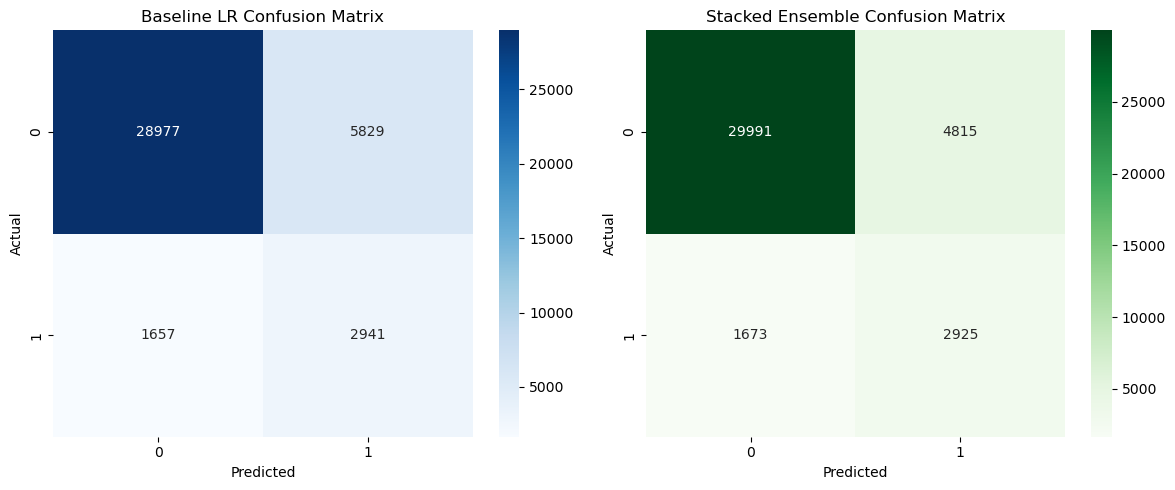

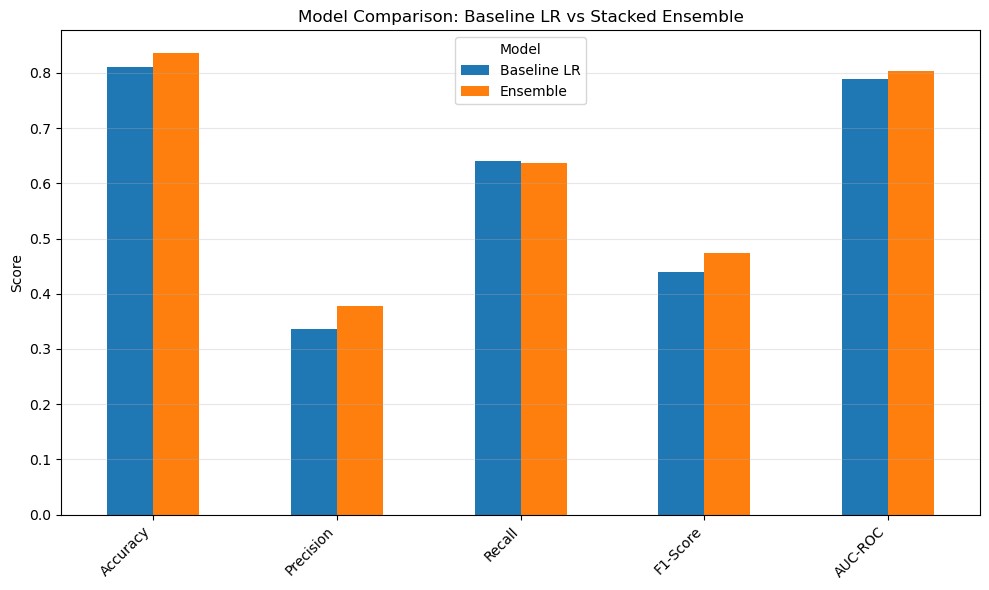

In [27]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Baseline
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Baseline LR Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Ensemble
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Stacked Ensemble Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# Metrics comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))
metrics_comparison[['Baseline LR', 'Ensemble']].plot(kind='bar', ax=ax)
ax.set_title('Model Comparison: Baseline LR vs Stacked Ensemble')
ax.set_ylabel('Score')
ax.set_xticklabels(metrics_comparison.index, rotation=45, ha='right')
ax.legend(title='Model')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
print('=' * 80)
print('BASELINE LOGISTIC REGRESSION - FEATURE INTERPRETATION')
print('=' * 80)

# Train final baseline LR on full dataset for interpretation
X_full = X.copy()
cat_cols = X_full.select_dtypes(include=['object', 'category']).columns.tolist()

# One-hot encode
X_full_encoded = pd.get_dummies(X_full, columns=cat_cols, drop_first=True)

# Scale
scaler_final = StandardScaler()
X_full_scaled = scaler_final.fit_transform(X_full_encoded)

# Compute class weights
cw_arr_final = compute_class_weight('balanced', classes=np.unique(y), y=y)

# Train final LR with median C from nested CV
median_C = np.median([fold['baseline_lr_auc'] for fold in outer_fold_detail])
# Use a reasonable default C since we don't store the actual C values
final_lr = LogisticRegression(
    C=1.0, 
    class_weight='balanced', 
    max_iter=1000, 
    random_state=RANDOM_STATE
)
final_lr.fit(X_full_scaled, y)

# Get feature names and coefficients
feature_names = X_full_encoded.columns.tolist()
coefficients = final_lr.coef_[0]

# Create dataframe of features and their importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print('\nTop 20 Most Important Features (by absolute coefficient):')
print('\nPositive coefficients increase subscription probability')
print('Negative coefficients decrease subscription probability\n')

top_20 = feature_importance.head(20)
for idx, row in top_20.iterrows():
    direction = '↑' if row['Coefficient'] > 0 else '↓'
    print(f"{row['Feature']:40s} {direction} {row['Coefficient']:8.4f}  (|{row['Abs_Coefficient']:.4f}|)")

print('\n' + '-' * 80)
print('\nFeature Insights:')
print('\nStrongest Positive Predictors (increase subscription likelihood):')
positive_top5 = feature_importance.nlargest(5, 'Coefficient')
for idx, row in positive_top5.iterrows():
    print(f"  • {row['Feature']:35s}: {row['Coefficient']:+.4f}")

print('\nStrongest Negative Predictors (decrease subscription likelihood):')
negative_top5 = feature_importance.nsmallest(5, 'Coefficient')
for idx, row in negative_top5.iterrows():
    print(f"  • {row['Feature']:35s}: {row['Coefficient']:+.4f}")

# Feature category analysis
print('\n' + '-' * 80)
print('\nFeature Category Analysis:')

def categorize_feature(feat_name):
    if any(x in feat_name.lower() for x in ['age', 'job_', 'marital_', 'education_', 'default', 'housing', 'loan']):
        return 'Demographics'
    elif any(x in feat_name.lower() for x in ['contact_', 'month_', 'day_of_week_']):
        return 'Campaign Contact'
    elif any(x in feat_name.lower() for x in ['campaign', 'previous']):
        return 'Campaign History'
    elif any(x in feat_name.lower() for x in ['euribor', 'cons.conf.idx']):
        return 'Socioeconomic'
    else:
        return 'Other'

feature_importance['Category'] = feature_importance['Feature'].apply(categorize_feature)

category_importance = feature_importance.groupby('Category').agg({
    'Abs_Coefficient': ['mean', 'sum', 'count']
}).round(4)

category_importance.columns = ['Avg_Importance', 'Total_Importance', 'Num_Features']
category_importance = category_importance.sort_values('Total_Importance', ascending=False)

print('\nImportance by Feature Category:')
print(category_importance.to_string())

BASELINE LOGISTIC REGRESSION - FEATURE INTERPRETATION

Top 20 Most Important Features (by absolute coefficient):

Positive coefficients increase subscription probability
Negative coefficients decrease subscription probability

euribor3m                                ↓  -0.7341  (|0.7341|)
contacted_before                         ↑   0.3805  (|0.3805|)
month_may                                ↓  -0.3147  (|0.3147|)
cons.conf.idx                            ↑   0.1852  (|0.1852|)
campaign                                 ↓  -0.1537  (|0.1537|)
contact_telephone                        ↓  -0.1365  (|0.1365|)
previous                                 ↓  -0.1346  (|0.1346|)
month_mar                                ↑   0.1287  (|0.1287|)
month_jul                                ↑   0.1179  (|0.1179|)
month_oct                                ↑   0.0955  (|0.0955|)
default_unknown                          ↓  -0.0911  (|0.0911|)
education_university.degree              ↑   0.0825  (|0.0825|)
month

## Business Perspective

In [29]:
print('\n' + '=' * 80)
print('BUSINESS METRICS (Financial ROI & Threshold Tuning)')
print('=' * 80)

# Business assumptions
COST_PER_CALL = 3
REVENUE_PER_CONV = 5_000 * 0.0125  # deposit * interest

print(f'\nBusiness Assumptions:')
print(f'  Cost per Call         : €{COST_PER_CALL:.2f}')
print(f'  Revenue per Conversion: €{REVENUE_PER_CONV:.2f}')
print(f'  Break-even Precision  : {COST_PER_CALL/REVENUE_PER_CONV:.1%}')

# ── Function to calculate business metrics ──────────────────────────────────

def calculate_business_metrics(y_true, y_pred_proba, model_name='Model'):
    """Calculate business metrics across thresholds"""
    
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    
    # Calculate F1 scores
    f1_scores = np.divide(
        2 * (precision * recall), 
        (precision + recall), 
        out=np.zeros_like(precision), 
        where=(precision + recall) != 0
    )
    
    # Calculate expected profit for every threshold
    profits = []
    total_actual_positives = sum(y_true)
    
    for p, r in zip(precision, recall):
        tp = r * total_actual_positives
        fp = (tp / p) - tp if p > 0 else 0
        profit = (tp * REVENUE_PER_CONV) - ((tp + fp) * COST_PER_CALL)
        profits.append(profit)
    
    profits = np.array(profits)
    
    # Find optimal threshold (max profit)
    optimal_idx = np.argmax(profits)
    optimal_threshold = thresholds[optimal_idx]
    max_profit = profits[optimal_idx]
    
    # Get metrics at optimal threshold
    y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_optimal)
    TN, FP, FN, TP = cm.ravel()
    
    total_calls = TP + FP
    conversion_rate = TP / total_calls if total_calls > 0 else 0
    
    return {
        'precision': precision,
        'recall': recall,
        'thresholds': thresholds,
        'f1_scores': f1_scores,
        'profits': profits,
        'optimal_threshold': optimal_threshold,
        'max_profit': max_profit,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'total_calls': total_calls,
        'conversion_rate': conversion_rate,
    }

# Calculate for both models
baseline_metrics = calculate_business_metrics(
    baseline_lr_true, baseline_lr_preds, 'Baseline LR'
)
ensemble_metrics = calculate_business_metrics(
    ensemble_true, ensemble_preds, 'Ensemble'
)

# ── Print Results ────────────────────────────────────────────────────────────

print('\n' + '-' * 80)
print('OPTIMAL THRESHOLD ANALYSIS (Profit Maximization)')
print('-' * 80)

print('\nBASELINE LOGISTIC REGRESSION:')
print(f'  Optimal Threshold     : {baseline_metrics["optimal_threshold"]:.3f}')
print(f'  Expected Profit       : €{baseline_metrics["max_profit"]:,.2f}')
print(f'  Total Calls Required  : {baseline_metrics["total_calls"]:,}')
print(f'  Campaign Conversion   : {baseline_metrics["conversion_rate"]:.1%}')
print(f'  True Positives (TP)   : {baseline_metrics["TP"]:,}  [Revenue: ${baseline_metrics["TP"] * REVENUE_PER_CONV:,.0f}]')
print(f'  False Positives (FP)  : {baseline_metrics["FP"]:,}  [Waste: ${baseline_metrics["FP"] * COST_PER_CALL:,.0f}]')
print(f'  False Negatives (FN)  : {baseline_metrics["FN"]:,}  [Missed: ${baseline_metrics["FN"] * REVENUE_PER_CONV:,.0f}]')

print('\nSTACKED ENSEMBLE:')
print(f'  Optimal Threshold     : {ensemble_metrics["optimal_threshold"]:.3f}')
print(f'  Expected Profit       : €{ensemble_metrics["max_profit"]:,.2f}')
print(f'  Total Calls Required  : {ensemble_metrics["total_calls"]:,}')
print(f'  Campaign Conversion   : {ensemble_metrics["conversion_rate"]:.1%}')
print(f'  True Positives (TP)   : {ensemble_metrics["TP"]:,}  [Revenue: ${ensemble_metrics["TP"] * REVENUE_PER_CONV:,.0f}]')
print(f'  False Positives (FP)  : {ensemble_metrics["FP"]:,}  [Waste: ${ensemble_metrics["FP"] * COST_PER_CALL:,.0f}]')
print(f'  False Negatives (FN)  : {ensemble_metrics["FN"]:,}  [Missed: ${ensemble_metrics["FN"] * REVENUE_PER_CONV:,.0f}]')

# ── Comparison ───────────────────────────────────────────────────────────────

profit_improvement = ensemble_metrics['max_profit'] - baseline_metrics['max_profit']
pct_improvement = 100 * profit_improvement / baseline_metrics['max_profit']

print('\n' + '-' * 80)
print('ENSEMBLE IMPROVEMENT OVER BASELINE:')
print(f'  Additional Profit     : €{profit_improvement:,.2f} ({pct_improvement:+.2f}%)')
print(f'  Calls Saved           : {baseline_metrics["total_calls"] - ensemble_metrics["total_calls"]:,}')
print(f'  Additional Conversions: {ensemble_metrics["TP"] - baseline_metrics["TP"]:,}')

# ── Random Calling Comparison ────────────────────────────────────────────────

print('\n' + '-' * 80)
print('COMPARISON TO RANDOM CALLING (Call Everyone)')
print('-' * 80)

total_positives = y.sum()
total_samples = len(y)
random_precision = total_positives / total_samples

random_calls = total_samples
random_conversions = total_positives
random_cost = random_calls * COST_PER_CALL
random_revenue = random_conversions * REVENUE_PER_CONV
random_profit = random_revenue - random_cost

print(f'\nRandom Strategy:')
print(f'  Calls Made            : {random_calls:,}')
print(f'  Conversions           : {random_conversions:,}')
print(f'  Precision             : {random_precision:.4f}')
print(f'  Net Profit            : €{random_profit:,.2f}')

print(f'\nBaseline LR vs Random:')
print(f'  Profit Improvement    : €{baseline_metrics["max_profit"] - random_profit:,.2f}')
print(f'  Calls Saved           : {random_calls - baseline_metrics["total_calls"]:,} ({100*(random_calls - baseline_metrics["total_calls"])/random_calls:.1f}%)')

print(f'\nEnsemble vs Random:')
print(f'  Profit Improvement    : €{ensemble_metrics["max_profit"] - random_profit:,.2f}')
print(f'  Calls Saved           : {random_calls - ensemble_metrics["total_calls"]:,} ({100*(random_calls - ensemble_metrics["total_calls"])/random_calls:.1f}%)')

# ── Top Decile Lift Analysis ─────────────────────────────────────────────────

print('\n' + '-' * 80)
print('RESOURCE CONSTRAINT ANALYSIS (Top 10% Lift)')
print('-' * 80)

n_customers = len(ensemble_true)
capacity_10pct = int(n_customers * 0.10)

# Baseline LR top 10%
baseline_sorted = np.argsort(baseline_lr_preds)[::-1]
baseline_top10_actuals = baseline_lr_true[baseline_sorted][:capacity_10pct]
baseline_conversions_10 = sum(baseline_top10_actuals)

# Ensemble top 10%
ensemble_sorted = np.argsort(ensemble_preds)[::-1]
ensemble_top10_actuals = ensemble_true[ensemble_sorted][:capacity_10pct]
ensemble_conversions_10 = sum(ensemble_top10_actuals)

random_conversions_10 = capacity_10pct * np.mean(ensemble_true)

baseline_lift = baseline_conversions_10 / random_conversions_10
ensemble_lift = ensemble_conversions_10 / random_conversions_10

print(f'\nConstraint: Marketing can only make {capacity_10pct:,} calls (10% of dataset)')
print(f'\nRandom Calling Yield  : ~{int(random_conversions_10)} conversions')
print(f'Baseline LR Yield     : {baseline_conversions_10} conversions (Lift: {baseline_lift:.2f}x)')
print(f'Ensemble Yield        : {ensemble_conversions_10} conversions (Lift: {ensemble_lift:.2f}x)')
print(f'\nEnsemble vs Baseline  : +{ensemble_conversions_10 - baseline_conversions_10} conversions')

print('=' * 80)


BUSINESS METRICS (Financial ROI & Threshold Tuning)

Business Assumptions:
  Cost per Call         : €3.00
  Revenue per Conversion: €62.50
  Break-even Precision  : 4.8%

--------------------------------------------------------------------------------
OPTIMAL THRESHOLD ANALYSIS (Profit Maximization)
--------------------------------------------------------------------------------

BASELINE LOGISTIC REGRESSION:
  Optimal Threshold     : 0.240
  Expected Profit       : €177,615.50
  Total Calls Required  : 30,774
  Campaign Conversion   : 14.0%
  True Positives (TP)   : 4,319  [Revenue: $269,938]
  False Positives (FP)  : 26,455  [Waste: $79,365]
  False Negatives (FN)  : 279  [Missed: $17,438]

STACKED ENSEMBLE:
  Optimal Threshold     : 0.272
  Expected Profit       : €182,125.00
  Total Calls Required  : 25,125
  Campaign Conversion   : 16.4%
  True Positives (TP)   : 4,120  [Revenue: $257,500]
  False Positives (FP)  : 21,005  [Waste: $63,015]
  False Negatives (FN)  : 478  [Missed:

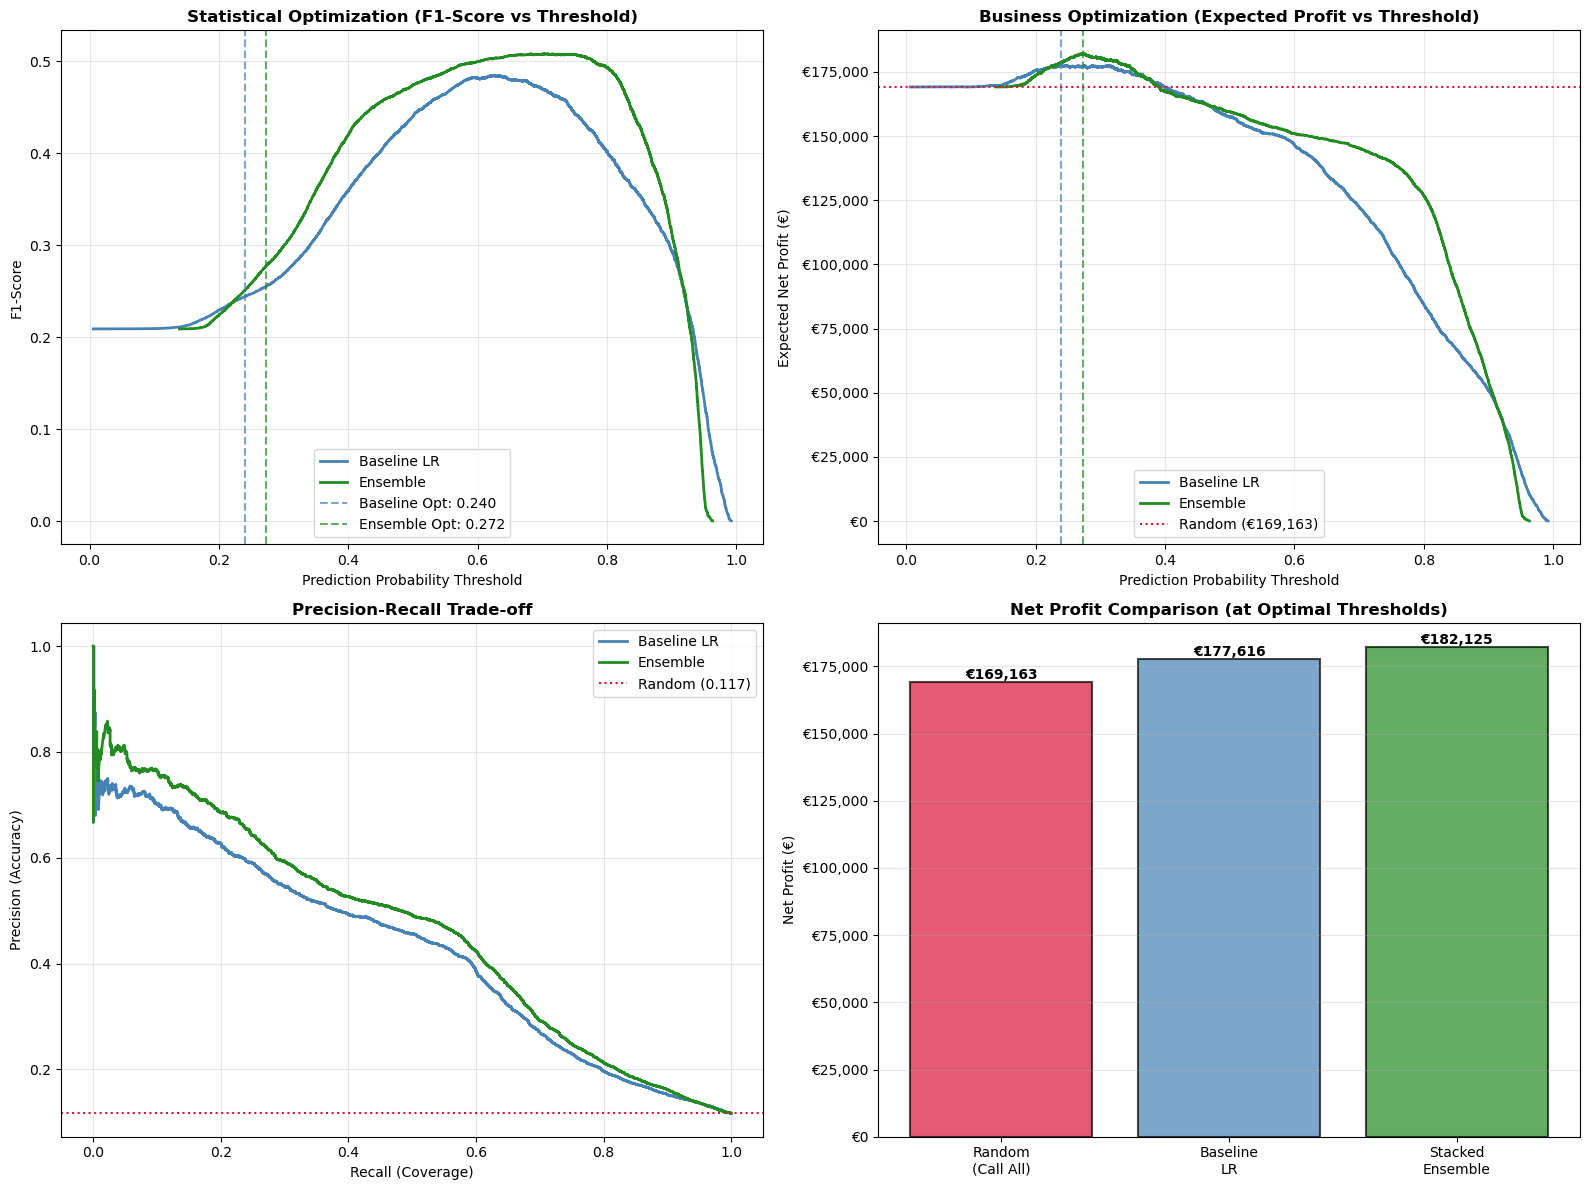

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1: F1-Score vs Threshold ────────────────────────────────────────────

axes[0, 0].plot(baseline_metrics['thresholds'], baseline_metrics['f1_scores'][:-1], 
                color='steelblue', lw=2, label='Baseline LR')
axes[0, 0].plot(ensemble_metrics['thresholds'], ensemble_metrics['f1_scores'][:-1], 
                color='forestgreen', lw=2, label='Ensemble')
axes[0, 0].axvline(x=baseline_metrics['optimal_threshold'], color='steelblue', 
                   linestyle='--', alpha=0.7, label=f'Baseline Opt: {baseline_metrics["optimal_threshold"]:.3f}')
axes[0, 0].axvline(x=ensemble_metrics['optimal_threshold'], color='forestgreen', 
                   linestyle='--', alpha=0.7, label=f'Ensemble Opt: {ensemble_metrics["optimal_threshold"]:.3f}')
axes[0, 0].set_title('Statistical Optimization (F1-Score vs Threshold)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Prediction Probability Threshold')
axes[0, 0].set_ylabel('F1-Score')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ── Plot 2: Expected Profit vs Threshold ─────────────────────────────────────

axes[0, 1].plot(baseline_metrics['thresholds'], baseline_metrics['profits'][:-1], 
                color='steelblue', lw=2, label='Baseline LR')
axes[0, 1].plot(ensemble_metrics['thresholds'], ensemble_metrics['profits'][:-1], 
                color='forestgreen', lw=2, label='Ensemble')
axes[0, 1].axvline(x=baseline_metrics['optimal_threshold'], color='steelblue', 
                   linestyle='--', alpha=0.7)
axes[0, 1].axvline(x=ensemble_metrics['optimal_threshold'], color='forestgreen', 
                   linestyle='--', alpha=0.7)
axes[0, 1].axhline(y=random_profit, color='crimson', linestyle=':', lw=1.5, 
                   label=f'Random (€{random_profit:,.0f})')
axes[0, 1].set_title('Business Optimization (Expected Profit vs Threshold)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Prediction Probability Threshold')
axes[0, 1].set_ylabel('Expected Net Profit (€)')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f" €{int(x):,}"))
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── Plot 3: Precision-Recall Curve ───────────────────────────────────────────

axes[1, 0].plot(baseline_metrics['recall'][:-1], baseline_metrics['precision'][:-1], 
                color='steelblue', lw=2, label='Baseline LR')
axes[1, 0].plot(ensemble_metrics['recall'][:-1], ensemble_metrics['precision'][:-1], 
                color='forestgreen', lw=2, label='Ensemble')
axes[1, 0].axhline(y=random_precision, color='crimson', linestyle=':', lw=1.5, 
                   label=f'Random ({random_precision:.3f})')
axes[1, 0].set_title('Precision-Recall Trade-off', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Recall (Coverage)')
axes[1, 0].set_ylabel('Precision (Accuracy)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ── Plot 4: Profit Comparison Bar Chart ──────────────────────────────────────

models = ['Random\n(Call All)', 'Baseline\nLR', 'Stacked\nEnsemble']
profits_compare = [random_profit, baseline_metrics['max_profit'], ensemble_metrics['max_profit']]
colors = ['crimson', 'steelblue', 'forestgreen']

bars = axes[1, 1].bar(models, profits_compare, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_title('Net Profit Comparison (at Optimal Thresholds)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Net Profit (€)')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"€{int(x):,}"))
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, profit in zip(bars, profits_compare):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'€{profit:,.0f}',
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Build Model

In [31]:
# ============================================================================
# 2. HYPERPARAMETER GRIDS
# ============================================================================
 
GRIDS = {
    'rf': {
        'n_estimators':       [100, 300, 500],
        'max_depth':          [10, None],
    },
    'knn': {
        'n_neighbors': [10, 20, 30, 40, 50],
        'weights': ['uniform', 'distance'],
    },
    'xgb': {
        'n_estimators':       [100, 300],
        'learning_rate':      [0.01, 0.05, 0.1],
    },
    'nb': {
        'var_smoothing': np.logspace(-10, -8, 5).tolist(),
    },
}
 
print('\n[2/5] Hyperparameter grids:')
for name, grid in GRIDS.items():
    n_combos = np.prod([len(v) for v in grid.values()]) if grid else 1
    print(f'  {name:5s}: {n_combos:3.0f} combinations')
 
# ============================================================================
# 3. PREPROCESSING PIPELINE
# ============================================================================
 
print('\n[3/5] Fitting preprocessing pipeline...')
 
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
 
# TREE dataset: Target Encoding (NO smoothing parameter - uses default)
X_tree = X.copy()
te = ce.TargetEncoder(cols=cat_cols)
X_tree[cat_cols] = te.fit_transform(X_tree[cat_cols], y)
X_tree = X_tree.values  # Convert to numpy array
 
# LINEAR dataset: One-Hot + StandardScaler
X_linear = pd.get_dummies(X, columns=cat_cols, drop_first=True)
linear_feature_names = X_linear.columns.tolist()  # Save for later alignment
scaler_linear = StandardScaler()
X_linear = scaler_linear.fit_transform(X_linear)  # Returns numpy array
 
print(f'  Tree features: {X_tree.shape[1]} (numpy array)')
print(f'  Linear features: {X_linear.shape[1]} (numpy array)')
 
# Class weights
cw = compute_class_weight('balanced', classes=np.unique(y), y=y)
pos_weight = cw[1] / cw[0]
 
# ============================================================================
# 4. HYPERPARAMETER TUNING (5-FOLD CV)
# ============================================================================
 
print('\n[4/5] Hyperparameter tuning...')
 
inner_cv = StratifiedKFold(n_splits=N_INNER_FOLDS, shuffle=True, random_state=RANDOM_STATE)
 
def run_gridsearch(estimator, param_grid, X_tr, y_tr, name):
    """Run GridSearchCV, return best estimator."""
    gs = GridSearchCV(
        estimator, param_grid, cv=inner_cv, scoring='roc_auc',
        refit=True, n_jobs=-1, verbose=0
    )
    gs.fit(X_tr, y_tr)
    print(f'  {name:4s} | AUC: {gs.best_score_:.4f} | {gs.best_params_}')
    return gs.best_estimator_
 
start = time.time()
 
# RF (tree dataset, class_weight='balanced')
best_rf = run_gridsearch(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    GRIDS['rf'], X_tree, y, 'RF'
)
 
# KNN (linear dataset, no class_weight)
best_knn = run_gridsearch(
    KNeighborsClassifier(n_jobs=-1),
    GRIDS['knn'], X_linear, y, 'KNN'
)
 
# XGB (tree dataset, scale_pos_weight)
best_xgb = run_gridsearch(
    XGBClassifier(scale_pos_weight=pos_weight, random_state=RANDOM_STATE, 
                  eval_metric='auc', n_jobs=-1),
    GRIDS['xgb'], X_tree, y, 'XGB'
)
 
# NB (linear dataset, var_smoothing tuning)
best_nb = run_gridsearch(
    GaussianNB(),
    GRIDS['nb'], X_linear, y, 'NB'
)
 
print(f'  Tuning time: {time.time() - start:.1f}s')
 
# ============================================================================
# 5. GENERATE OOF META-FEATURES (5-FOLD CV)
# ============================================================================
 
print('\n[5/5] Generating OOF meta-features...')
 
n_samples = len(y)
meta_train = np.zeros((n_samples, 4))
 
cv_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
for fold, (tr_idx, val_idx) in enumerate(cv_oof.split(X_tree, y), 1):
    y_tr = y[tr_idx]
    
    # Recompute class weights per fold
    cw_fold = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    pw_fold = cw_fold[1] / cw_fold[0]
    
    # RF - extract ONLY tuned hyperparams
    m = RandomForestClassifier(
        **{k: v for k, v in best_rf.get_params().items() 
           if k in ['n_estimators', 'max_depth']},
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    )
    m.fit(X_tree[tr_idx], y_tr)
    meta_train[val_idx, 0] = m.predict_proba(X_tree[val_idx])[:, 1]
    
    # KNN
    m = KNeighborsClassifier(
        **{k: v for k, v in best_knn.get_params().items() 
           if k in ['n_neighbors', 'weights']},
        n_jobs=-1
    )
    m.fit(X_linear[tr_idx], y_tr)
    meta_train[val_idx, 1] = m.predict_proba(X_linear[val_idx])[:, 1]
    
    # XGB
    m = XGBClassifier(
        **{k: v for k, v in best_xgb.get_params().items() 
           if k in ['n_estimators', 'learning_rate']},
        scale_pos_weight=pw_fold, random_state=RANDOM_STATE,
        eval_metric='auc', n_jobs=-1
    )
    m.fit(X_tree[tr_idx], y_tr)
    meta_train[val_idx, 2] = m.predict_proba(X_tree[val_idx])[:, 1]
    
    # NB
    m = GaussianNB(**best_nb.get_params())
    m.fit(X_linear[tr_idx], y_tr)
    meta_train[val_idx, 3] = m.predict_proba(X_linear[val_idx])[:, 1]
 
print(f'  Meta-features shape: {meta_train.shape}')
 
# Base model OOF AUCs
base_aucs = {
    'RF':  roc_auc_score(y, meta_train[:, 0]),
    'KNN': roc_auc_score(y, meta_train[:, 1]),
    'XGB': roc_auc_score(y, meta_train[:, 2]),
    'NB':  roc_auc_score(y, meta_train[:, 3]),
}
 
print('\n  Base model OOF AUCs:')
for name, auc in sorted(base_aucs.items(), key=lambda x: x[1], reverse=True):
    print(f'    {name:4s}: {auc:.4f}')
 
# ============================================================================
# 6. TRAIN META-MODEL
# ============================================================================
 
print('\n[6/7] Training meta-model...')
 
meta_model = LogisticRegression(
    random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'
)
meta_model.fit(meta_train, y)
 
ensemble_auc = roc_auc_score(y, meta_model.predict_proba(meta_train)[:, 1])
print(f'  Ensemble OOF AUC: {ensemble_auc:.4f}')
 
# ============================================================================
# 7. RETRAIN FINAL BASE MODELS ON FULL DATA
# ============================================================================
 
print('\n[7/7] Retraining final base models on full data...')
 
final_rf = RandomForestClassifier(
    **{k: v for k, v in best_rf.get_params().items() 
       if k in ['n_estimators', 'max_depth']},
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
final_rf.fit(X_tree, y)
 
final_knn = KNeighborsClassifier(
    **{k: v for k, v in best_knn.get_params().items() 
       if k in ['n_neighbors', 'weights']},
    n_jobs=-1
)
final_knn.fit(X_linear, y)
 
final_xgb = XGBClassifier(
    **{k: v for k, v in best_xgb.get_params().items() 
       if k in ['n_estimators', 'learning_rate']},
    scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
    eval_metric='auc', n_jobs=-1
)
final_xgb.fit(X_tree, y)
 
final_nb = GaussianNB(**best_nb.get_params())
final_nb.fit(X_linear, y)
 
print('  ✓ Final models trained')
 
# ============================================================================
# 8. SAVE MODELS & PREPROCESSING
# ============================================================================
 
print('\n[8/8] Saving models...')
 
# Base models
pickle.dump(final_rf, open('../Model & Dataset/rf_final.pkl', 'wb'))
pickle.dump(final_knn, open('../Model & Dataset/knn_final.pkl', 'wb'))
pickle.dump(final_xgb, open('../Model & Dataset/xgb_final.pkl', 'wb'))
pickle.dump(final_nb, open('../Model & Dataset/nb_final.pkl', 'wb'))
 
# Meta-model
pickle.dump(meta_model, open('../Model & Dataset/meta_lr.pkl', 'wb'))
 
# Preprocessing (fitted objects)
pickle.dump(te, open('../Model & Dataset/target_encoder.pkl', 'wb'))
pickle.dump(scaler_linear, open('../Model & Dataset/scaler.pkl', 'wb'))
 
# Feature metadata
pickle.dump({
    'cat_cols': cat_cols,
    'linear_feature_names': linear_feature_names,
}, open('../Model & Dataset/feature_metadata.pkl', 'wb'))
 
print('    - Base models: rf_final.pkl, knn_final.pkl, xgb_final.pkl, nb_final.pkl')
print('    - Meta-model: meta_lr.pkl')
print('    - Preprocessing: target_encoder.pkl, scaler.pkl')
print('    - Metadata: feature_metadata.pkl')
 
print('\n' + '=' * 80)
print('TRAINING COMPLETE')
print('=' * 80)
print(f'\nEnsemble OOF AUC: {ensemble_auc:.4f}')


[2/5] Hyperparameter grids:
  rf   :   6 combinations
  knn  :  10 combinations
  xgb  :   6 combinations
  nb   :   5 combinations

[3/5] Fitting preprocessing pipeline...
  Tree features: 15 (numpy array)
  Linear features: 46 (numpy array)

[4/5] Hyperparameter tuning...
  RF   | AUC: 0.8014 | {'max_depth': 10, 'n_estimators': 500}
  KNN  | AUC: 0.7606 | {'n_neighbors': 50, 'weights': 'uniform'}
  XGB  | AUC: nan | {'learning_rate': 0.01, 'n_estimators': 100}
  NB   | AUC: 0.7544 | {'var_smoothing': 1e-10}
  Tuning time: 22.3s

[5/5] Generating OOF meta-features...
  Meta-features shape: (39404, 4)

  Base model OOF AUCs:
    RF  : 0.8011
    XGB : 0.8008
    KNN : 0.7604
    NB  : 0.7541

[6/7] Training meta-model...
  Ensemble OOF AUC: 0.8031

[7/7] Retraining final base models on full data...
  ✓ Final models trained

[8/8] Saving models...
    - Base models: rf_final.pkl, knn_final.pkl, xgb_final.pkl, nb_final.pkl
    - Meta-model: meta_lr.pkl
    - Preprocessing: target_encode